# Employee Churn Prediction System
## HR Analytics: End-to-End Machine Learning Pipeline

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees, 35 features)
**Goal:** Predict which employees will leave, enabling proactive HR retention interventions.
**random_state = 42** throughout.

## Imports and Settings

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pointbiserialr
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from datetime import datetime
import joblib
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, brier_score_loss,
    classification_report
)
from sklearn.base import clone



# Global settings
RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-pastel')
FIG_W, FIG_H = 14, 6

# Model output directory
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)


---
<a id='section1'></a>
## Section 1 — EDA & Preprocessing

Load the dataset, overview, handling missing values, detect outliers, assess class imbalance, and produce five targeted business visualizations.

### 1.1 — Load Data

In [30]:
RAW_URL = (
    "https://raw.githubusercontent.com/shantanu1109/"
    "IBM-HR-Analytics-Employee-Attrition-and-Performance-Prediction/"
    "main/DATASET/IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv"
)

def load_dataset(url: str) -> pd.DataFrame:
    """Download the IBM HR dataset from GitHub raw URL."""
    df = pd.read_csv(url)
    print(f"✓ Loaded  {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df

df_raw = load_dataset(RAW_URL)
df = df_raw.copy()
df.head()

✓ Loaded  1,470 rows × 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


### 1.2 — Initial Overview

In [31]:
print("=" * 55)
print(f"Shape : {df.shape[0]} rows  ×  {df.shape[1]} columns")
print("=" * 55)

dtype_summary = df.dtypes.value_counts()
print("\nColumn dtypes:")
for dtype, n in dtype_summary.items():
    print(f"  {str(dtype):10s}  {n} columns")

print("\nNumerical summary:")
df.describe().T.style.format("{:.2f}")

Shape : 1470 rows  ×  31 columns

Column dtypes:
  object      16 columns
  int64       15 columns

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Age,1470.00,36.92,9.14,18.00,30.00,36.00,43.00,60.00
DailyRate,1470.00,802.49,403.51,102.00,465.00,802.00,1157.00,1499.00
DistanceFromHome,1470.00,9.19,8.11,1.00,2.00,7.00,14.00,29.00
HourlyRate,1470.00,65.89,20.33,30.00,48.00,66.00,83.75,100.00
MonthlyIncome,1470.00,6502.93,4707.96,1009.00,2911.00,4919.00,8379.00,19999.00
MonthlyRate,1470.00,14313.10,7117.79,2094.00,8047.00,14235.50,20461.50,26999.00
NumCompaniesWorked,1470.00,2.69,2.50,0.00,1.00,2.00,4.00,9.00
PercentSalaryHike,1470.00,15.21,3.66,11.00,12.00,14.00,18.00,25.00
StockOptionLevel,1470.00,0.79,0.85,0.00,0.00,1.00,1.00,3.00
TotalWorkingYears,1470.00,11.28,7.78,0.00,6.00,10.00,15.00,40.00


### 1.3 — Missing Values

**Method & Reasoning:** Compute the count and percentage of nulls per column.
Because the IBM HR dataset is synthetically generated by IBM, it is clean by design, but if nulls were existed in continuous columns, We would impute with the *median* (robust to outliers); for categoricals we would use the *mode*.


In [32]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    """Return a sorted table of missing-value counts and percentages."""
    total = df.isnull().sum()
    pct   = (total / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': total, 'Pct (%)': pct})
    report = report[report['Missing'] > 0].sort_values('Missing', ascending=False)
    return report

missing = missing_report(df)
if missing.empty:
    print("No missing values found, dataset is complete.")
else:
    print(missing.to_string())

No missing values found, dataset is complete.


### 1.4 — Outlier Detection

We apply two complementary methods:
- **IQR (Tukey fence):** flags values outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR] — robust to non-normal distributions.
- **Z-score (|z| > 3):** appropriate when the column is approximately normal.

Identified outliers are **retained** (not removed) because they represent real employee scenarios (e.g. very high seniority). They are noted for monitoring.

In [33]:
def outlier_count_iqr(series: pd.Series) -> int:
    """Count values outside the Tukey 1.5×IQR fence."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

def outlier_count_zscore(series: pd.Series, threshold: float = 3.0) -> int:
    """Count values with |z-score| > threshold."""
    z = np.abs(stats.zscore(series.dropna()))
    return int((z > threshold).sum())

num_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []
for col in num_cols:
    iqr_n  = outlier_count_iqr(df[col])
    zscore_n = outlier_count_zscore(df[col])
    if iqr_n > 0 or zscore_n > 0:
        outlier_rows.append({
            'Feature': col,
            'IQR Outliers': iqr_n,
            'Z-score Outliers': zscore_n,
        })

outlier_df = pd.DataFrame(outlier_rows).sort_values('IQR Outliers', ascending=False)
print(f"Features with detected outliers: {len(outlier_df)}")
outlier_df.head(15)


Features with detected outliers: 9


,Feature,IQR Outliers,Z-score Outliers
4,TrainingTimesLastYear,238,0
0,MonthlyIncome,114,0
7,YearsSinceLastPromotion,107,42
5,YearsAtCompany,104,25
2,StockOptionLevel,85,0
3,TotalWorkingYears,63,16
1,NumCompaniesWorked,52,0
6,YearsInCurrentRole,21,13
8,YearsWithCurrManager,14,14


### 1.5 — Target Variable Distribution (Attrition)

We encode Attrition as binary (Yes→1, No→0) and measure class imbalance.

A ratio > 4:1 is considered problematic and requires handling.


No  (0):  1233  (83.9%)
Yes (1):   237  (16.1%)
Target ratio: 5.2:1


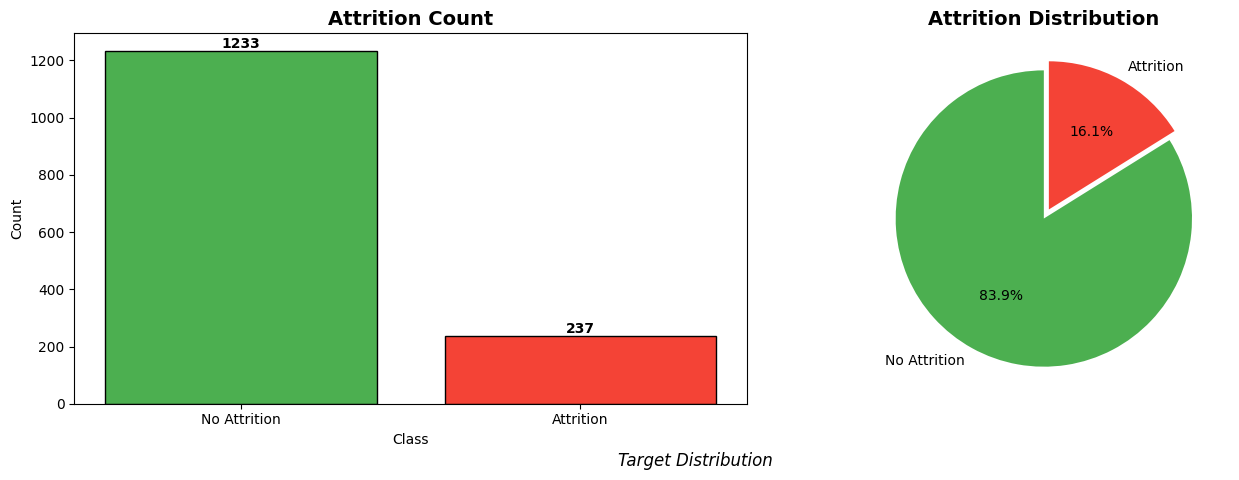

In [34]:
# Encode target
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
counts = df['Attrition'].value_counts().sort_index()   # sort so 0 is first
pct    = df['Attrition'].value_counts(normalize=True).sort_index() * 100
ratio = counts.iloc[0] / counts.iloc[1]

print(f"No  (0): {counts.iloc[0]:>5}  ({pct.iloc[0]:.1f}%)")
print(f"Yes (1): {counts.iloc[1]:>5}  ({pct.iloc[1]:.1f}%)")
print(f"Target ratio: {ratio:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Count bar
axes[0].bar(['No Attrition', 'Attrition'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_subtitle = None
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')

# Pie
axes[1].pie(counts.values, labels=['No Attrition', 'Attrition'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, explode=[0, 0.07])
axes[1].set_title('Attrition Distribution', fontsize=14, fontweight='bold')

fig.suptitle('Target Distribution',
             fontsize=12, style='italic', y=0.02)
plt.tight_layout()
plt.show()

**Target distribution indicates moderate class imbalance.**

### 1.6 — EDA Visualizations

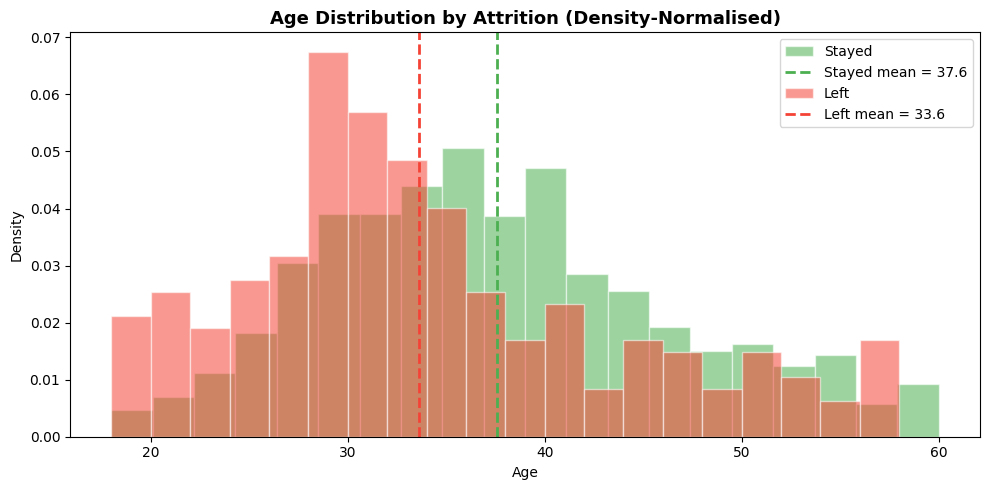

In [35]:
# # ── Viz 1: Age Distribution by Attrition ─────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, '#4CAF50', 'Stayed'), (1, '#F44336', 'Left')]:
    subset = df[df['Attrition'] == label]['Age']
    ax.hist(subset, bins=20, color=color, edgecolor='white',
            alpha=0.55, label=name, density=True)
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=2,
               label=f'{name} mean = {subset.mean():.1f}')

ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Attrition (Density-Normalised)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

**From the Age distribution we can see that younger employees (25-35) leave more often**

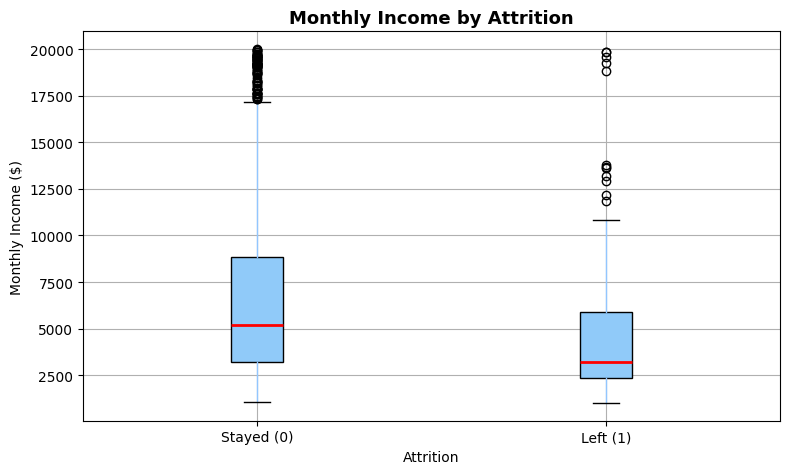

In [36]:
# # ── Viz 2: Monthly Income vs Attrition ───────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='MonthlyIncome', by='Attrition', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#90CAF9'),
           medianprops=dict(color='red', linewidth=2))

ax.set_xticklabels(['Stayed (0)', 'Left (1)'])
ax.set_title('Monthly Income by Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Monthly Income ($)')

plt.suptitle('')   # removes the default "Boxplot grouped by Attrition" title pandas adds
plt.tight_layout()
plt.show()

**From the Monthly income vs attrion we can see that employees who leave earn less on average**

Top 15 features correlated with Attrition:
TotalWorkingYears         -0.171
YearsInCurrentRole        -0.161
MonthlyIncome             -0.160
Age                       -0.159
YearsWithCurrManager      -0.156
StockOptionLevel          -0.137
YearsAtCompany            -0.134
DistanceFromHome           0.078
TrainingTimesLastYear     -0.059
DailyRate                 -0.057
NumCompaniesWorked         0.043
YearsSinceLastPromotion   -0.033
MonthlyRate                0.015
PercentSalaryHike         -0.013
HourlyRate                -0.007


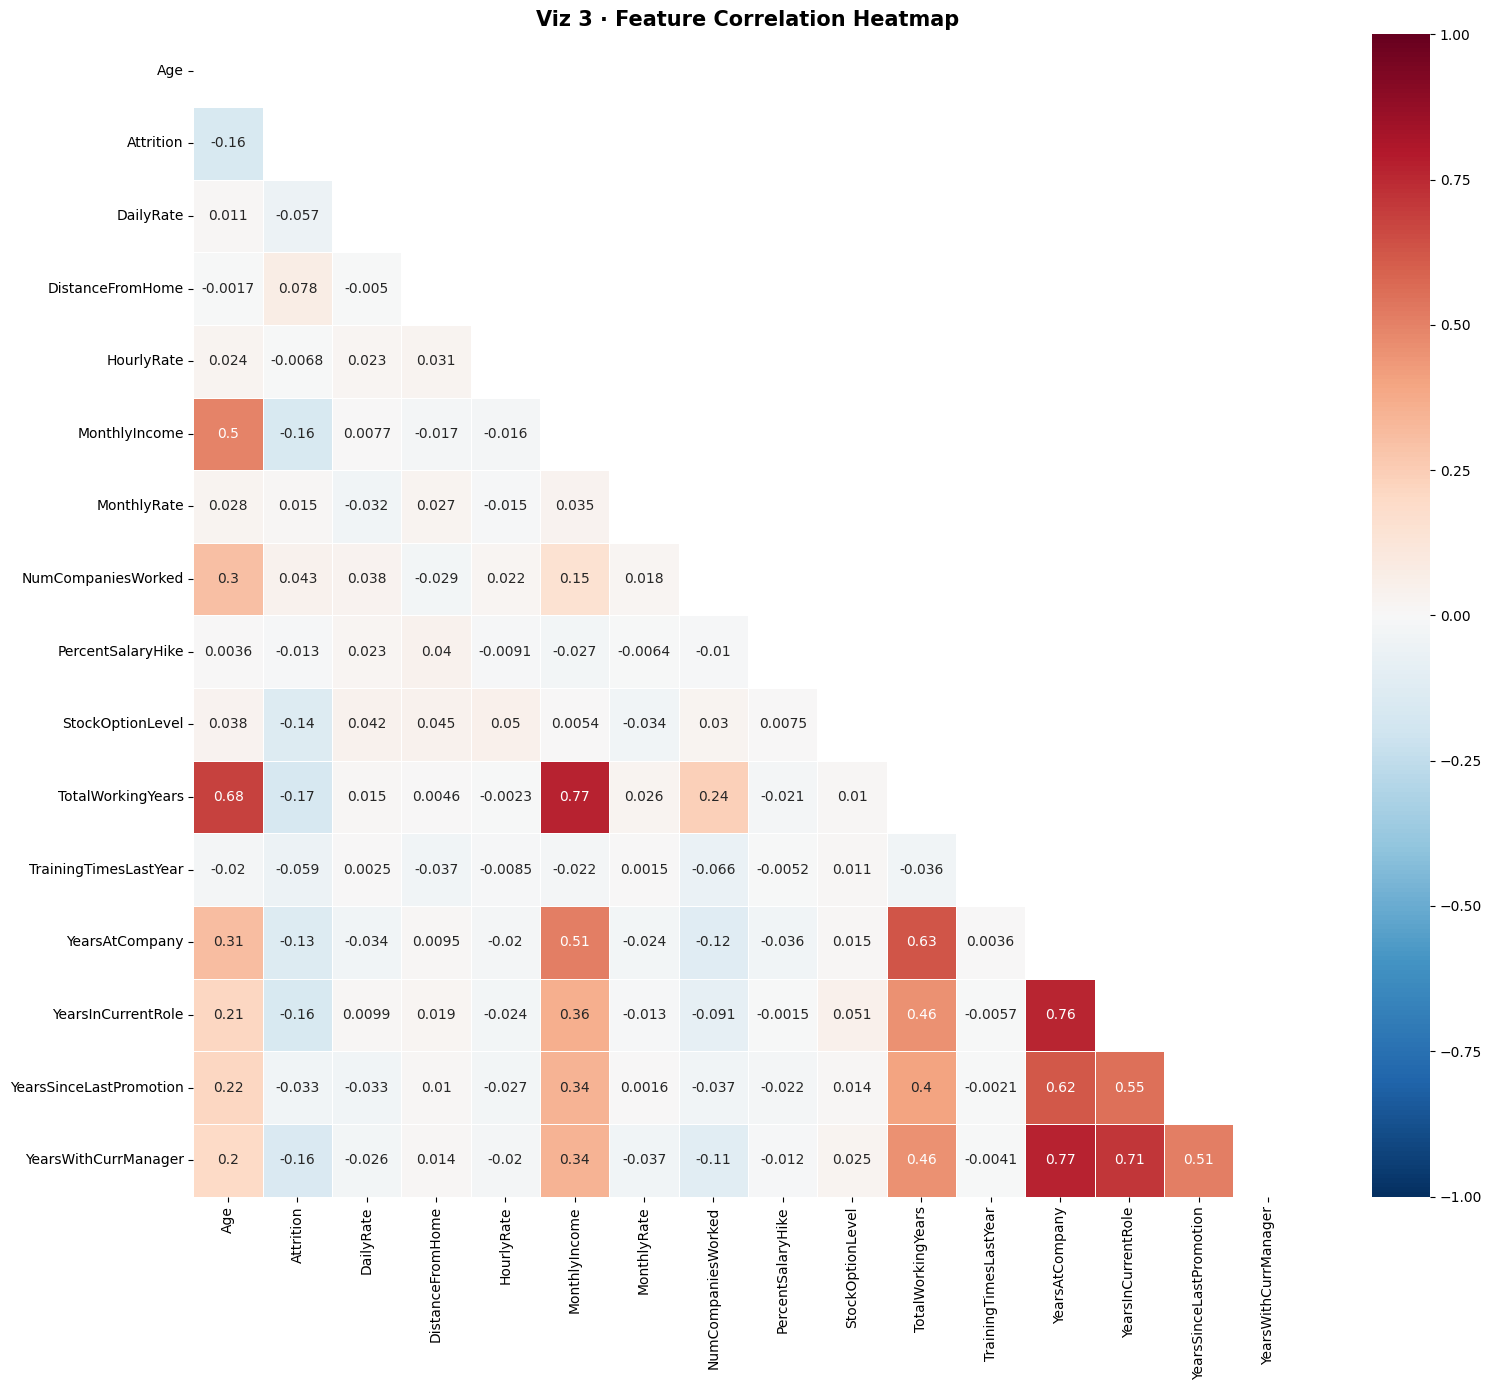

In [37]:
# ── Viz 3: Correlation Heatmap ────────────────────────────────────────────
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

# Highlight top correlations with Attrition
top_corr = (corr['Attrition']
            .drop('Attrition')                                      # exclude self-correlation
            .sort_values(key=lambda s: s.abs(), ascending=False)    # sort by |r|, keep sign
            .head(15))

print("Top 15 features correlated with Attrition:")
print(top_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, linewidths=0.4, ax=ax, vmin=-1, vmax=1)
ax.set_title('Viz 3 · Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**From the strong correlation between TotalWorkingYears, YearsInCurrentRole and MonthlyIncome, we can see that the more years an employee has been with the company and the higher their salary, the less likely they are to leave.**

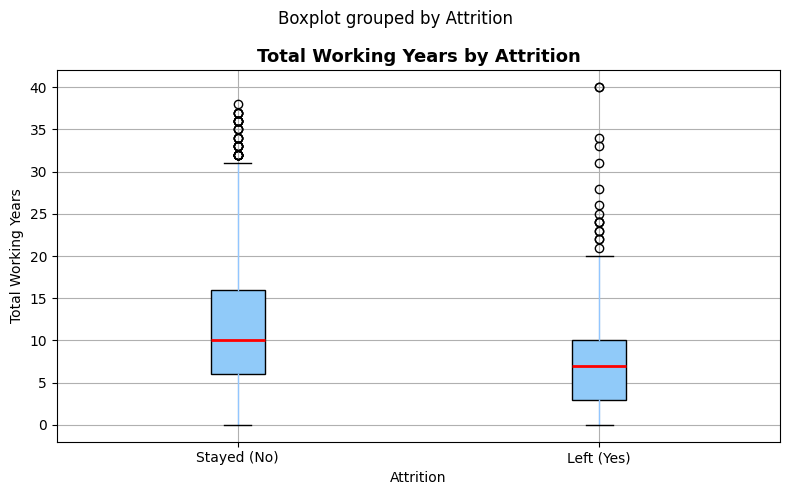

In [38]:
# ── Viz 4: Total Working Years vs Attrition ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='TotalWorkingYears', by='Attrition', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#90CAF9'),
           medianprops=dict(color='red', linewidth=2))

ax.set_xticklabels(['Stayed (No)', 'Left (Yes)'])
ax.set_title('Total Working Years by Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Total Working Years')

plt.tight_layout()
plt.show()

Because TotalWorkingYears showed the highest correlation with the target variable, we display its boxplot as well. We can see that employees who leave tend to have fewer total working years.

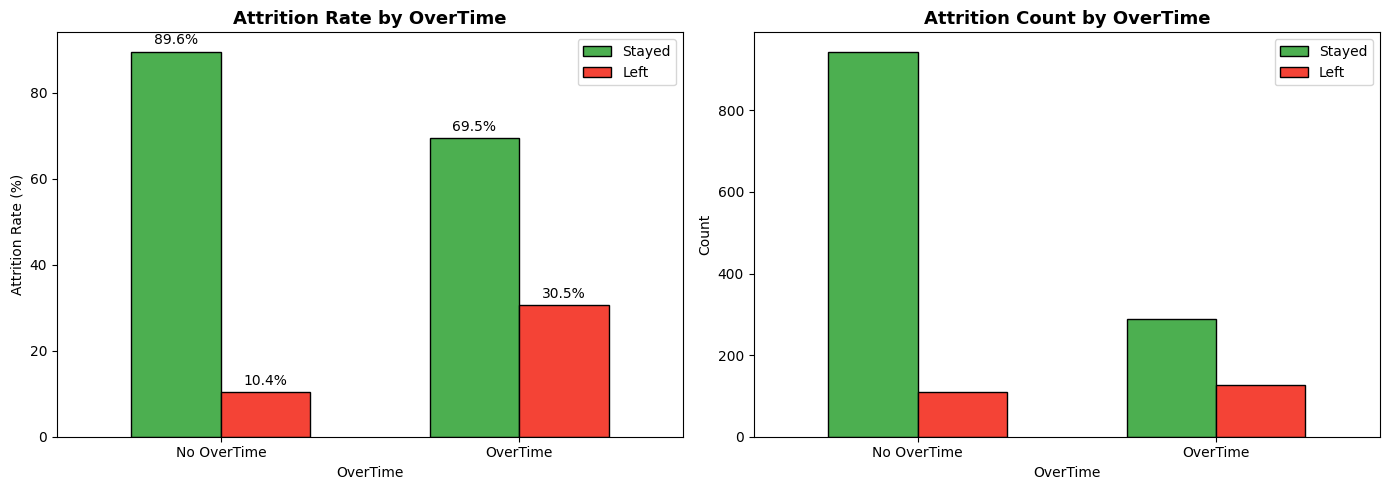

In [39]:
# ── Viz 5: Overtime vs Attrition ─────────────────────────────────────────
ot_crosstab = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

ot_crosstab.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'],
                 edgecolor='black', width=0.6)
axes[0].set_xlabel('OverTime'); axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by OverTime', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No OverTime', 'OverTime'], rotation=0)
axes[0].legend(['Stayed', 'Left'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# Raw counts
ot_counts = pd.crosstab(df['OverTime'], df['Attrition'])
ot_counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'],
               edgecolor='black', width=0.6)
axes[1].set_xlabel('OverTime'); axes[1].set_ylabel('Count')
axes[1].set_title('Attrition Count by OverTime', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No OverTime', 'OverTime'], rotation=0)
axes[1].legend(['Stayed', 'Left'])

plt.tight_layout()
plt.show()

**Employees who work more overtime are more likely to leave**

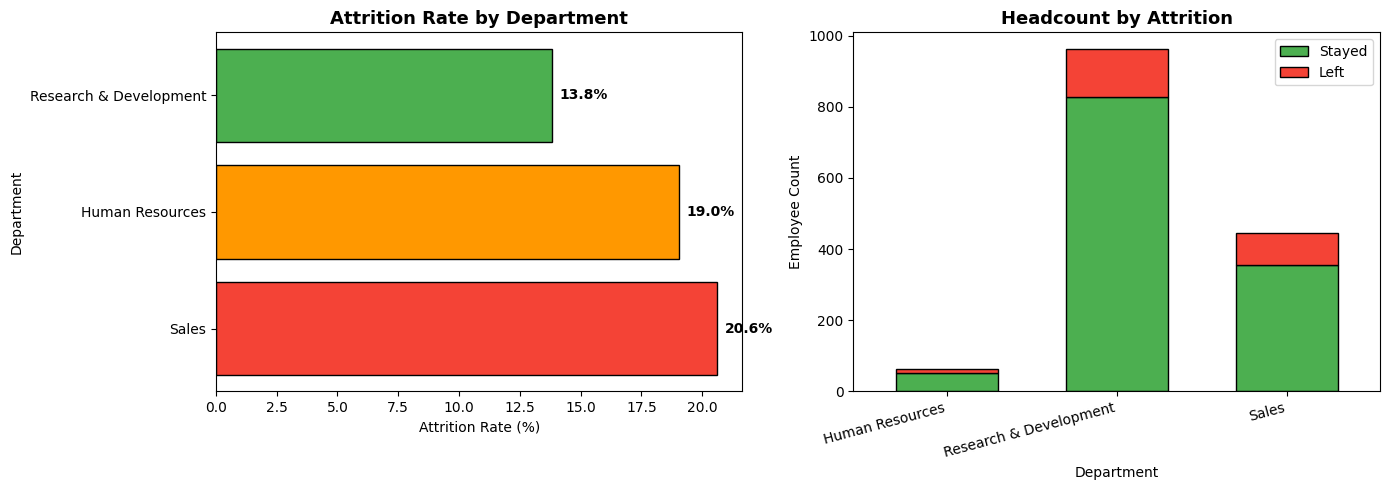

In [40]:
# ── Viz 6: Department vs Attrition Rate ──────────────────────────────────
dept_rate = (df.groupby('Department')['Attrition']
               .agg(['mean', 'sum', 'count'])
               .rename(columns={'mean': 'Rate', 'sum': 'Churned', 'count': 'Total'}))
dept_rate['Rate'] = dept_rate['Rate'] * 100
dept_rate = dept_rate.sort_values('Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

bars = axes[0].barh(dept_rate.index, dept_rate['Rate'],
                    color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='black')
axes[0].set_xlabel('Attrition Rate (%)'); axes[0].set_ylabel('Department')
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
for bar, rate in zip(bars, dept_rate['Rate']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontweight='bold')

# Stacked bar
dept_abs = pd.crosstab(df['Department'], df['Attrition'])
dept_abs.columns = ['Stayed', 'Left']
dept_abs.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#4CAF50', '#F44336'], edgecolor='black', width=0.6)
axes[1].set_xlabel('Department'); axes[1].set_ylabel('Employee Count')
axes[1].set_title('Headcount by Attrition', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

**Sales has the highest rate of attrition(~21%), R&D has the lowest rate (~14%).**

### 1.7 — Statistical Analysis by Attrition Class

In [41]:
# Keep only columns that are actually numeric in the dataframe
key_num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'Attrition']

stat_table = (df.groupby('Attrition')[key_num_cols]
                .agg(['mean', 'median', 'std'])
                .round(2)
                .T
                .rename(columns={0: 'No', 1: 'Yes'}, level=0))
stat_table

Attrition                             No       Yes
Age                     mean       37.56     33.61
                        median     36.00     32.00
                        std         8.89      9.69
DailyRate               mean      812.50    750.36
                        median    817.00    699.00
                        std       403.21    401.90
DistanceFromHome        mean        8.92     10.63
                        median      7.00      9.00
                        std         8.01      8.45
HourlyRate              mean       65.95     65.57
                        median     66.00     66.00
                        std        20.38     20.10
MonthlyIncome           mean     6832.74   4787.09
                        median   5204.00   3202.00
                        std      4818.21   3640.21
MonthlyRate             mean    14265.78  14559.31
                        median  14120.00  14618.00
                        std      7102.26   7208.15
NumCompaniesWorked      mean        2.65      2.94
                        median      2.00      1.00
                        std         2.46      2.68
PercentSalaryHike       mean       15.23     15.10
                        median     14.00     14.00
                        std         3.64      3.77
StockOptionLevel        mean        0.85      0.53
                        median      1.00      0.00
                        std         0.84      0.86
TotalWorkingYears       mean       11.86      8.24
                        median     10.00      7.00
                        std         7.76      7.17
TrainingTimesLastYear   mean        2.83      2.62
                        median      3.00      2.00
                        std         1.29      1.25
YearsAtCompany          mean        7.37      5.13
                        median      6.00      3.00
                        std         6.10      5.95
YearsInCurrentRole      mean        4.48      2.90
                        median      3.00      2.00
                        std         3.65      3.17
YearsSinceLastPromotion mean        2.23      1.95
                        median      1.00      1.00
                        std         3.23      3.15
YearsWithCurrManager    mean        4.37      2.85
                        median      3.00      2.00
                        std         3.59      3.14

---
<a id='section2'></a>
## Section 2 — Feature Engineering

We create six domain-informed features. Every feature is derived solely from columns present in the raw dataset, using no information about the target variable. this guarantees no data leakage.
The features are computed *before* the train/test split. the split is done in Section 3 so the train-time statistics (mean, std for scaling) are learned only from training data.



| Feature | Calculation | What it measures | Expected effect on attrition |
|---|---|---|---|
| `Income_to_TotalWorkingYears` | `MonthlyIncome / (TotalWorkingYears + 1)` | Is the employee well-paid for their experience? | Higher → lower risk (well-compensated for experience level) |
| `Tenure_Ratio` | `YearsAtCompany / (TotalWorkingYears + 1)` | What share of their career has been at this company? | Higher → lower risk (more invested in the company) |
| `Satisfaction_Score` | `mean(rank(JobSatisfaction), rank(EnvironmentSatisfaction), rank(RelationshipSatisfaction), rank(WorkLifeBalance))` where rank: 1=Low, 2=Medium, 3=High, 4=Very High | How happy are they overall? | Higher → lower risk (more engaged and content) |
| `Promotion_Lag_Ratio` | `YearsSinceLastPromotion / (YearsAtCompany + 1)` | How long ago was their last promotion, relative to how long they've been here? | Higher → higher risk (feeling stuck or overlooked) |
| `Career_Growth_Rate` | `JobLevel / (TotalWorkingYears + 1)` | How fast have they climbed the job levels compared to their experience? | Higher → lower risk (career is progressing) |
| `Manager_Stability` | `YearsWithCurrManager / (YearsAtCompany + 1)` | How much of their time here was spent under the same manager? | Higher → lower risk (stable relationship with manager) |

In [42]:
def encode_ordinal_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Apply ordinal encoding to columns that use categorical labels."""
    out = df.copy()

    # JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction: 1=Low … 4=Very High
    sat_map = {1: 1, 2: 2, 3: 3, 4: 4,
               'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}

    # WorkLifeBalance: 1=Bad, 2=Good, 3=Better, 4=Best
    wlb_map = {1: 1, 2: 2, 3: 3, 4: 4,
               'Bad': 1, 'Good': 2, 'Better': 3, 'Best': 4}

    # JobLevel: 1=Entry … 5=Executive
    joblevel_map = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5,
                    'Entry Level': 1, 'Junior Level': 2, 'Mid Level': 3,
                    'Senior Level': 4, 'Executive Level': 5}

    # BusinessTravel: frequency of travel increases risk
    travel_map = {'Non-Travel': 1, 'Travel_Rarely': 2, 'Travel_Frequently': 3}

    # Education: Below College … Doctor
    education_map = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5,
                     'Below College': 1, 'College': 2, 'Bachelor': 3,
                     'Master': 4, 'Doctor': 5}

    # JobInvolvement: Low … Very High
    involvement_map = {1: 1, 2: 2, 3: 3, 4: 4,
                       'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}

    # PerformanceRating: Low … Outstanding
    performance_map = {1: 1, 2: 2, 3: 3, 4: 4,
                       'Low': 1, 'Good': 2, 'Excellent': 3, 'Outstanding': 4}

    for col in ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']:
        out[col] = out[col].map(sat_map)
    out['WorkLifeBalance']   = out['WorkLifeBalance'].map(wlb_map)
    out['JobLevel']          = out['JobLevel'].map(joblevel_map)
    out['BusinessTravel']    = out['BusinessTravel'].map(travel_map)
    out['Education']         = out['Education'].map(education_map)
    out['JobInvolvement']    = out['JobInvolvement'].map(involvement_map)
    out['PerformanceRating'] = out['PerformanceRating'].map(performance_map)

    return out


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df_c = encode_ordinal_columns(df)
    df_out = pd.DataFrame()

    # monthly income divided by total working years (+1 avoids division by zero)
    df_out['Income_to_TotalWorkingYears'] = df_c['MonthlyIncome'] / (df_c['TotalWorkingYears'] + 1)

    # years at company as fraction of total career (+1 avoids division by zero)
    df_out['Tenure_Ratio'] = df_c['YearsAtCompany'] / (df_c['TotalWorkingYears'] + 1)

    # mean of the four ordinal ranks
    sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
    df_out['Satisfaction_Score'] = df_c[sat_cols + ['WorkLifeBalance']].mean(axis=1)

    # years since promotion relative to current tenure
    df_out['Promotion_Lag_Ratio'] = df_c['YearsSinceLastPromotion'] / (df_c['YearsAtCompany'] + 1)

    # job level achieved per year of total experience
    df_out['Career_Growth_Rate'] = df_c['JobLevel'] / (df_c['TotalWorkingYears'] + 1)

    # years with current manager as fraction of company tenure
    df_out['Manager_Stability'] = df_c['YearsWithCurrManager'] / (df_c['YearsAtCompany'] + 1)

    return df_out


df_new_feats = engineer_features(df)

print('Engineered features created:')
df_new_feats.describe().T.round(3)

Engineered features created:


,count,mean,std,min,25%,50%,75%,max
Income_to_TotalWorkingYears,1470.0,587.575,284.651,95.286,374.232,549.221,738.304,1904.000
Tenure_Ratio,1470.0,0.582,0.284,0.000,0.368,0.636,0.833,0.976
Satisfaction_Score,1470.0,2.731,0.506,1.000,2.500,2.750,3.000,4.000
Promotion_Lag_Ratio,1470.0,0.236,0.269,0.000,0.000,0.143,0.429,0.917
Career_Growth_Rate,1470.0,0.207,0.122,0.048,0.125,0.182,0.250,1.000
Manager_Stability,1470.0,0.466,0.277,0.000,0.286,0.500,0.667,0.895


Visualise the 6 new features split by Attrition

In [43]:
df_new_feats.columns

Index(['Income_to_TotalWorkingYears', 'Tenure_Ratio', 'Satisfaction_Score',
       'Promotion_Lag_Ratio', 'Career_Growth_Rate', 'Manager_Stability'],
      dtype='object')

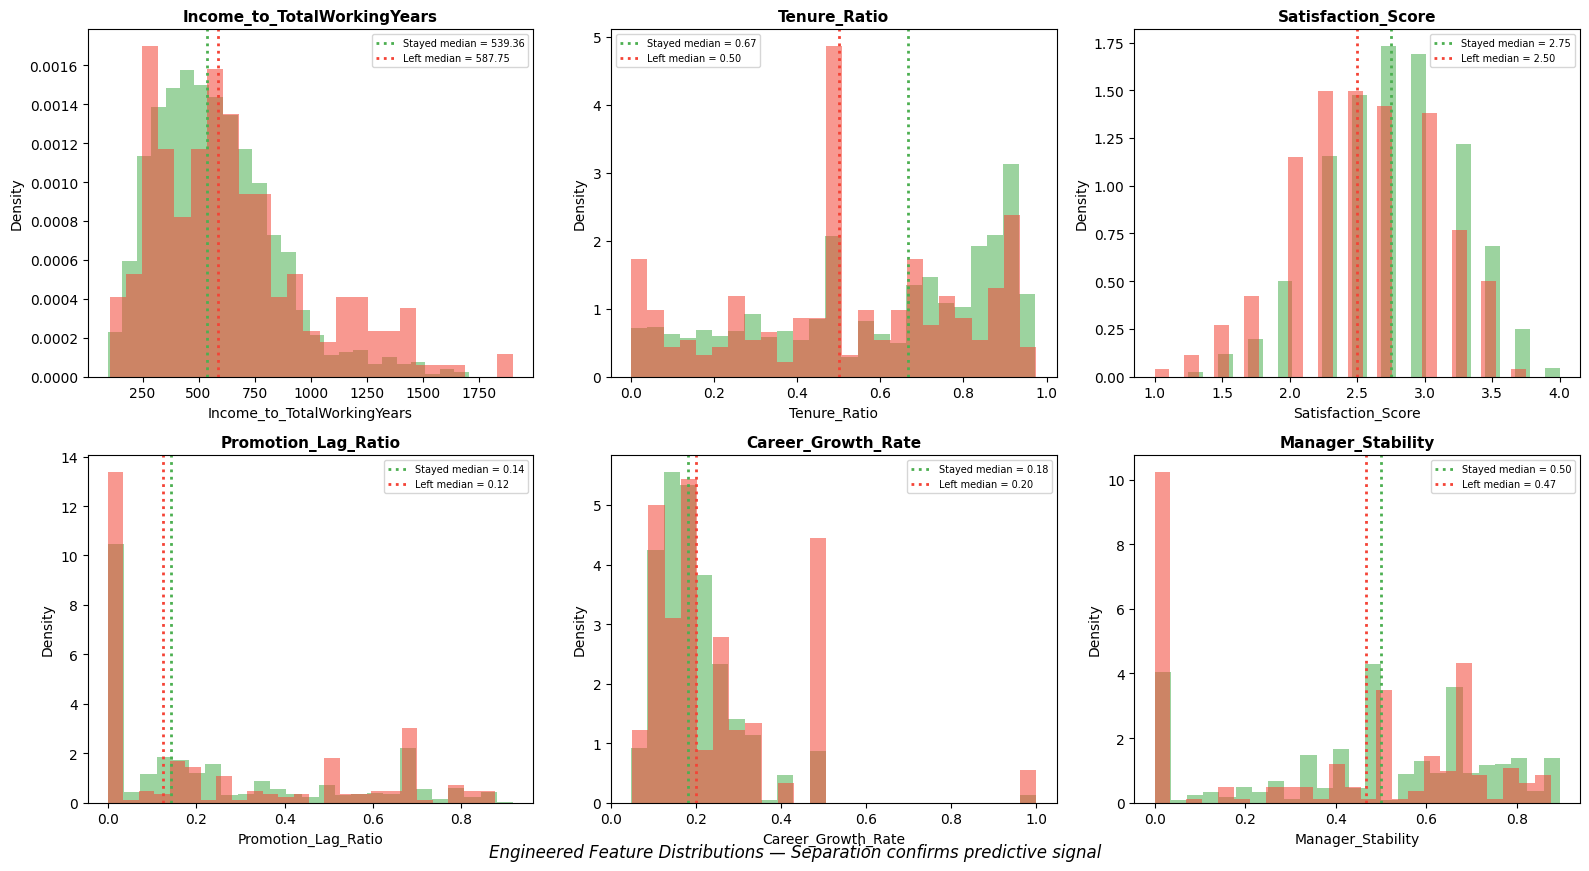

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(FIG_W + 2, 9))

for ax, feat in zip(axes.flat, df_new_feats.columns):
    for label, color, name in [(0, '#4CAF50', 'Stayed'), (1, '#F44336', 'Left')]:
        subset = df_new_feats[df['Attrition'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.55, color=color, density=True)
        ax.axvline(subset.median(), color=color, linestyle=':', linewidth=2,
                   label=f'{name} median = {subset.median():.2f}')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

fig.suptitle('Engineered Feature Distributions — Separation confirms predictive signal',
             fontsize=12, style='italic', y=0.02)
plt.tight_layout()
plt.show()


---
<a id='section3'></a>
## Section 3 — Transformations, Scaling & Normalization

### Why scaling matters and when it doesn't
- **StandardScaler** (zero mean, unit variance) is used in Logistic Regression / SVM: gradient-based optimisers converge much faster and produce correctly-weighted coefficients when all features share the same scale.
- **MinMaxScaler** (range [0,1]) is preferred for neural networks and algorithms that interpret values as probabilities/intensities.
- **Random Forest / Gradient Boosting:** split thresholds are scale-invariant, so only relative orderings matter. Scaling is harmless but unnecessary.

### Data-leakage risk of pre-split scaling
If we fit a scaler on the *entire* dataset before splitting, the test set's statistics contaminate the scaler parameters (mean/std), inflating reported performance. The fix: **fit scalers only on training data** using `sklearn.pipeline.Pipeline`, which enforces this automatically during cross-validation.

#### Define features and target

In [45]:
TARGET = 'Attrition'

cat_features = df.select_dtypes(include='object').columns.tolist()
num_features  = [c for c in df.select_dtypes(include=np.number).columns
                 if c != TARGET]

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numerical features  ({len(num_features)}): {num_features}")

# Join the 6 engineered features (computed in Section 2) into X
X = pd.concat([df.drop(columns=[TARGET]), df_new_feats], axis=1)
y = df[TARGET]

print(f"\nFeature matrix shape after adding engineered features: {X.shape}")
print(f"Engineered features added: {df_new_feats.columns.tolist()}")

Categorical features (15): ['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance']
Numerical features  (15): ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Feature matrix shape after adding engineered features: (1470, 36)
Engineered features added: ['Income_to_TotalWorkingYears', 'Tenure_Ratio', 'Satisfaction_Score', 'Promotion_Lag_Ratio', 'Career_Growth_Rate', 'Manager_Stability']


#### split
 70 / 15 / 15 split (stratified)
 
Justification:
* train 70%- sufficient for complex tree models on a 1470-row dataset.
* val 15%- hyperparameter selection without touching test.
* test 15%- held-out, seen exactly once for final reported metrics.

In [46]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
val_size = 0.15 / 0.85   # 15% of total from the remaining 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"\nTrain : {len(X_train):>4} rows  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):>4} rows  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):>4} rows  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nAttrition frequency — train {y_train.mean():.3f} | val {y_val.mean():.3f} | test {y_test.mean():.3f}")



Train : 1028 rows  (69.9%)
Val   :  221 rows  (15.0%)
Test  :  221 rows  (15.0%)

Attrition frequency — train 0.161 | val 0.163 | test 0.163


### Encoding Strategy

We split categorical columns into two groups:

- **Ordinal columns** (e.g. `JobLevel`, `Education`, `PerformanceRating`)- have a natural order, so we map them to integers using `encode_ordinal_columns`. The result is treated as numeric and passed to `StandardScaler`. Because this mapping is a fixed lookup table (no statistics learned from the data), applying it to all splits is safe and introduces no leakage.

- **Nominal columns** (e.g. `Department`, `JobRole`, `Gender`)- have no meaningful order, so we use `OneHotEncoder` which creates a binary column per category.

Both transformations are wrapped in a `ColumnTransformer` that is **fit only on training data** and then applied to validation and test sets separately.


In [47]:
# Columns encoded ordinally — pure lookup, no statistics learned, so no leakage risk
ORDINAL_COLS = [c for c in [
    'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction',
    'WorkLifeBalance', 'JobLevel', 'BusinessTravel', 'Education',
    'JobInvolvement', 'PerformanceRating'
] if c in X_train.columns]

# Apply ordinal encoding to each split independently
X_train_enc = encode_ordinal_columns(X_train)
X_val_enc   = encode_ordinal_columns(X_val)
X_test_enc  = encode_ordinal_columns(X_test)

# After encoding, ordinal cols are integers and join the numeric group.
# Remaining object columns are true nominals so they go to OneHotEncoder.
NUM_COLS = [c for c in X_train_enc.select_dtypes(include=np.number).columns]
OHE_COLS = [c for c in X_train_enc.select_dtypes(include='object').columns]

print(f"Ordinal-encoded cols ({len(ORDINAL_COLS)}): {ORDINAL_COLS}")
print(f"OHE cols            ({len(OHE_COLS)}): {OHE_COLS}")
print(f"Numeric cols        ({len(NUM_COLS)}): {NUM_COLS}")

Ordinal-encoded cols (9): ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'JobLevel', 'BusinessTravel', 'Education', 'JobInvolvement', 'PerformanceRating']
OHE cols            (6): ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numeric cols        (30): ['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Income_to_TotalWorkingYears', 'Tenure_Ratio', 'Satisfaction_Score', 'Promotion_Lag_Ratio', 'Career_Growth_Rate', 'Manager_Stability']


### Preprocess

In [48]:
def make_preprocessor() -> ColumnTransformer:
    """
    StandardScaler on numeric + ordinal-encoded columns.
    OneHotEncoder on remaining nominal categorical columns.
    Fit only on training data- transform val/test separately.
    """
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False,
                              drop='first'), OHE_COLS)
    ], remainder='drop')


preprocessor = make_preprocessor()

X_train_proc = preprocessor.fit_transform(X_train_enc, y_train)
X_val_proc   = preprocessor.transform(X_val_enc)
X_test_proc  = preprocessor.transform(X_test_enc)

feature_names_out = preprocessor.get_feature_names_out()
print(f"Processed feature count : {X_train_proc.shape[1]}")
print(f"processed names  : {list(feature_names_out)}")

Processed feature count : 49
processed names  : ['num__Age', 'num__BusinessTravel', 'num__DailyRate', 'num__DistanceFromHome', 'num__Education', 'num__EnvironmentSatisfaction', 'num__HourlyRate', 'num__JobInvolvement', 'num__JobLevel', 'num__JobSatisfaction', 'num__MonthlyIncome', 'num__MonthlyRate', 'num__NumCompaniesWorked', 'num__PercentSalaryHike', 'num__PerformanceRating', 'num__RelationshipSatisfaction', 'num__StockOptionLevel', 'num__TotalWorkingYears', 'num__TrainingTimesLastYear', 'num__WorkLifeBalance', 'num__YearsAtCompany', 'num__YearsInCurrentRole', 'num__YearsSinceLastPromotion', 'num__YearsWithCurrManager', 'num__Income_to_TotalWorkingYears', 'num__Tenure_Ratio', 'num__Satisfaction_Score', 'num__Promotion_Lag_Ratio', 'num__Career_Growth_Rate', 'num__Manager_Stability', 'cat__Department_Research & Development', 'cat__Department_Sales', 'cat__EducationField_Life Sciences', 'cat__EducationField_Marketing', 'cat__EducationField_Medical', 'cat__EducationField_Other', 'cat__Ed

---
<a id='section4'></a>
## Section 4 — Model Training

### Class imbalance strategy
| Approach | Pros | Cons |
|---|---|---|
| `class_weight='balanced'` | Fast, no synthetic data, no risk of overfitting resampled region | Only reweights loss, can under-perform on very skewed ratios |
| `scale_pos_weight` (XGBoost) | Native XGBoost parameter — equivalent to class weighting but built in to the boosting objective | Requires computing the ratio manually |

**Decision:** `class_weight='balanced'` for LR and SVM; `scale_pos_weight` for XGBoost (set to `n_negatives / n_positives` from the training set).

### Models trained
1. **Logistic Regression** — linear baseline, highly interpretable
2. **Random Forest** — robust ensemble, low tuning effort
3. **XGBoost** — gradient boosted trees with native imbalance handling, typically high AUC
4. **SVM (RBF kernel)** — effective in high-dimensional space, good boundary

### Define 4 pipelines

In [49]:
# scale_pos_weight = negatives / positives in training set — handles class imbalance natively in XGBoost
scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight = {scale_pos_weight}  ({(y_train==0).sum()} negatives / {(y_train==1).sum()} positives)")

pipelines = {
    'Logistic Regression': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', LogisticRegression(
            class_weight='balanced', C=0.5,
            max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs'
        ))
    ]),
    'Random Forest': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', RandomForestClassifier(
            class_weight='balanced', n_estimators=200,
            max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            n_estimators=200, learning_rate=0.05,
            max_depth=4, random_state=RANDOM_STATE,
            eval_metric='logloss', n_jobs=-1
        ))
    ]),
    'SVM': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', SVC(
            class_weight='balanced', kernel='rbf',
            probability=True, C=1.0, gamma='scale',
            random_state=RANDOM_STATE
        ))
    ])
}

scale_pos_weight = 5  (863 negatives / 165 positives)


### Train all models

In [50]:
trained = {}
for name, pipe in pipelines.items():
    print(f"Training {name} ...", end='\n')
    pipe.fit(X_train_enc, y_train)
    trained[name] = pipe

print("\nAll models trained.")

Training Logistic Regression ...
Training Random Forest ...
Training XGBoost ...
Training SVM ...

All models trained.


### Save all models with timestamp versioning

In [51]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

for name, pipe in trained.items():
    slug = name.lower().replace(' ', '_')
    path = MODELS_DIR / f"{slug}_v{timestamp}.pkl"
    joblib.dump(pipe, path)
    print(f"{path} \t saved")

print(f"\nAll {len(trained)} models saved to {MODELS_DIR}/")

models/logistic_regression_v20260606_1548.pkl 	 saved
models/random_forest_v20260606_1548.pkl 	 saved
models/xgboost_v20260606_1548.pkl 	 saved
models/svm_v20260606_1548.pkl 	 saved

All 4 models saved to models/


---
<a id='section5'></a>
## Section 5 — Validation & Model Selection

Accuracy- is not enough on its own because the dataset is imbalanced (~84% stay, ~16% leave). A model that always predicts "stay" would achieve 84% accuracy while being completely useless and would never catch a single leaver.

FN cost- missed a leaver:
We predicted the employee would stay, but they actually left. This is the most costly mistake, we lose a talented employee with no chance to intervene.

FP cost- false alarm:
We predicted the employee would leave, but they actually stayed. This leads to unnecessary HR intervention (manager conversation, salary raise), which wastes resources but causes no serious harm.

Precision vs Recall- Recall is more important here. We want to catch as many actual leavers as possible, even if it means some false alarms. Missing a leaver (FN) is far more costly than a unnecessary HR intervention (FP).

F1-Score- This is it relevant when we need a single metric that balances both Precision and Recall. Useful when both false positives and false negatives carry significant cost. In our case it's a good secondary metric, but Recall remains the priority.

ROC-AUC- Measures how well the model separates the two classes across all possible thresholds. A score of 1.0 is perfect, 0.5 is random guessing. Good for comparing models, but can be misleading with imbalanced data.

PR-AUC- ROC-AUC can look artificially high with imbalanced data because it accounts for TN, which are abundant. PR-AUC focuses only on the positive class (leavers), making it a more honest measure of performance when the positive class is rare.

### Validation on 15% validation data

In [52]:
def evaluate_pipeline(pipe, X, y, threshold: float = 0.5) -> dict:
    """Return a dict of classification metrics for one model."""
    proba  = pipe.predict_proba(X)[:, 1]
    preds  = (proba >= threshold).astype(int)
    return {
        'Accuracy':  round(accuracy_score(y, preds), 4),
        'Precision': round(precision_score(y, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y, preds, zero_division=0), 4),
        'F1':        round(f1_score(y, preds, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y, proba), 4),
        'PR-AUC':    round(average_precision_score(y, proba), 4),
    }

# Evaluate on validation set
val_results = {name: evaluate_pipeline(pipe, X_val_enc, y_val)
               for name, pipe in trained.items()}
results_df = pd.DataFrame(val_results).T.sort_values('ROC-AUC', ascending=False)
print("Validation metrics:")
results_df


Validation metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7511,0.3766,0.8056,0.5133,0.8146,0.5960
XGBoost,0.8416,0.5135,0.5278,0.5205,0.7878,0.5721
Random Forest,0.8552,0.7500,0.1667,0.2727,0.7713,0.5009
SVM,0.8643,0.6364,0.3889,0.4828,0.7704,0.5077


### Stratified 5-fold CV on train+val

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

X_tv = pd.concat([X_train_enc, X_val_enc])
y_tv = pd.concat([y_train, y_val])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'Accuracy':  'accuracy',
    'Precision': 'precision',
    'Recall':    'recall',
    'F1':        'f1',
    'ROC-AUC':   'roc_auc',
    'PR-AUC':    'average_precision',
}

cv_rows = {}
for name, pipe in pipelines.items():
    scores = cross_validate(clone(pipe), X_tv, y_tv, cv=cv,
                            scoring=SCORING, n_jobs=-1)
    cv_rows[name] = {metric: round(scores[f'test_{metric}'].mean(), 4)
                     for metric in SCORING}

cv_df = (pd.DataFrame(cv_rows).T
           .sort_values('ROC-AUC', ascending=False))
print("CV metrics (5-fold mean):")
cv_df


CV metrics (5-fold mean):


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7582,0.3734,0.7161,0.4892,0.8143,0.6051
SVM,0.8319,0.4843,0.6067,0.5373,0.8121,0.5908
Random Forest,0.8535,0.7742,0.1494,0.2459,0.7894,0.5274
XGBoost,0.8487,0.5371,0.4727,0.5003,0.7798,0.5537


### Learning Curves

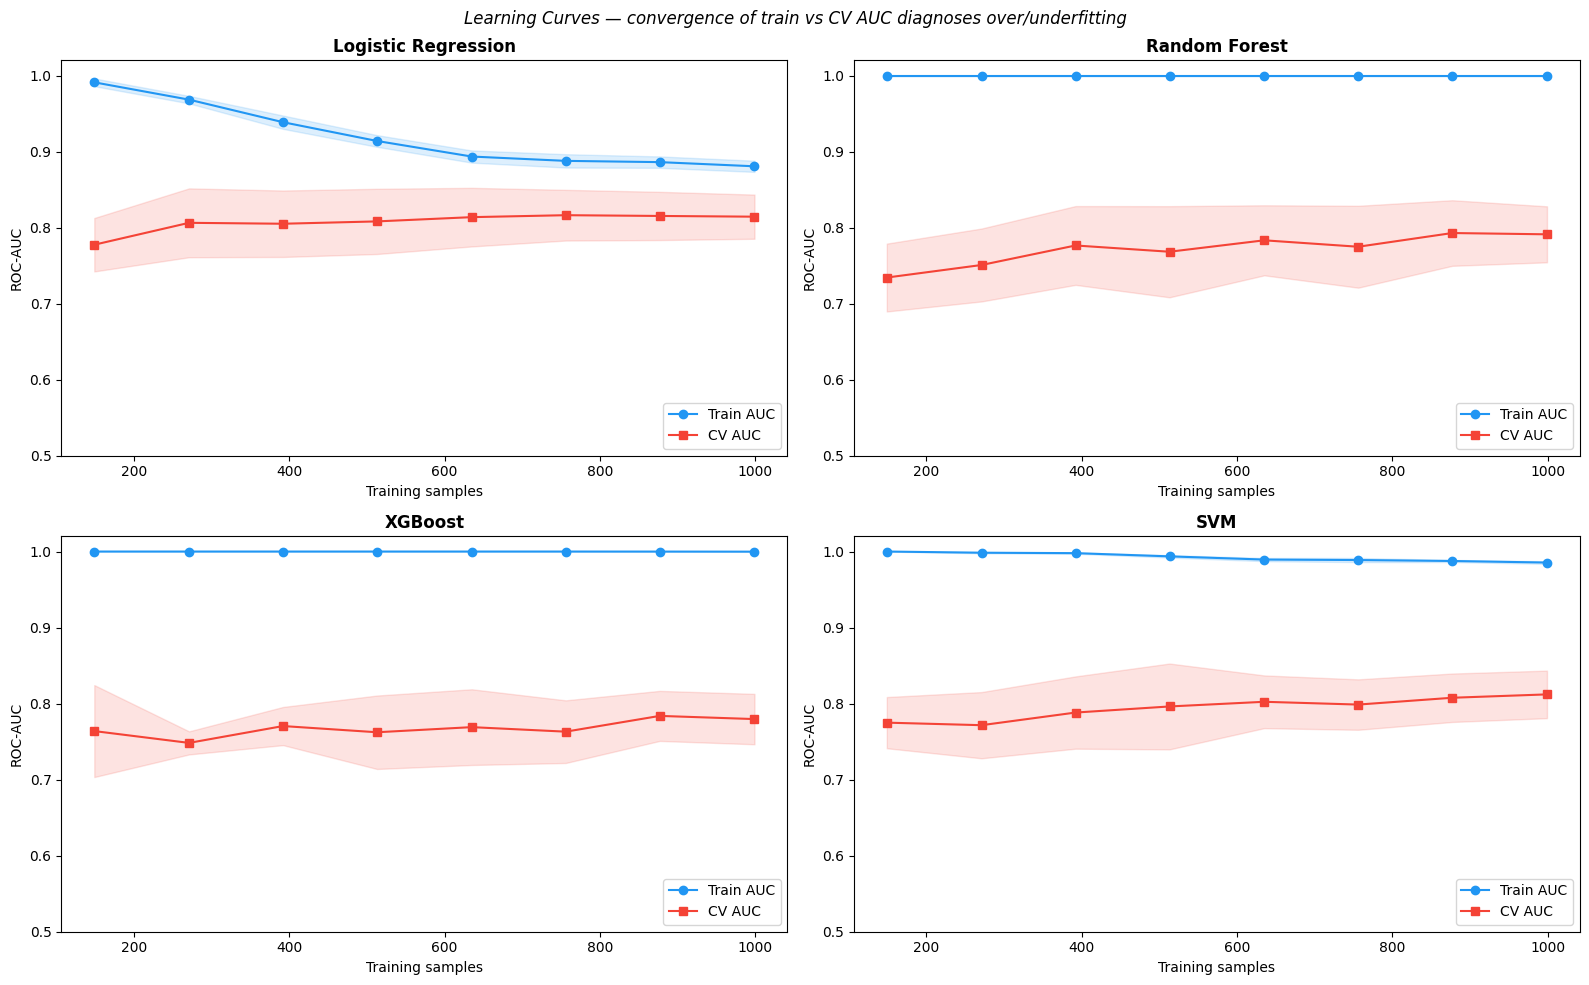

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(FIG_W + 2, 10))

for ax, (name, pipe) in zip(axes.flat, pipelines.items()):
    cloned_pipe = clone(pipe)
    train_sizes, train_scores, val_scores = learning_curve(
        cloned_pipe, X_tv, y_tv,
        train_sizes=np.linspace(0.15, 1.0, 8),
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    vl_mean = val_scores.mean(axis=1)
    vl_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#2196F3', label='Train AUC')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#2196F3')
    ax.plot(train_sizes, vl_mean, 's-', color='#F44336', label='CV AUC')
    ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color='#F44336')
    ax.set_xlabel('Training samples'); ax.set_ylabel('ROC-AUC')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_ylim(0.5, 1.02)

fig.suptitle('Learning Curves — convergence of train vs CV AUC diagnoses over/underfitting',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

### Confusion Matrices — Validation Set

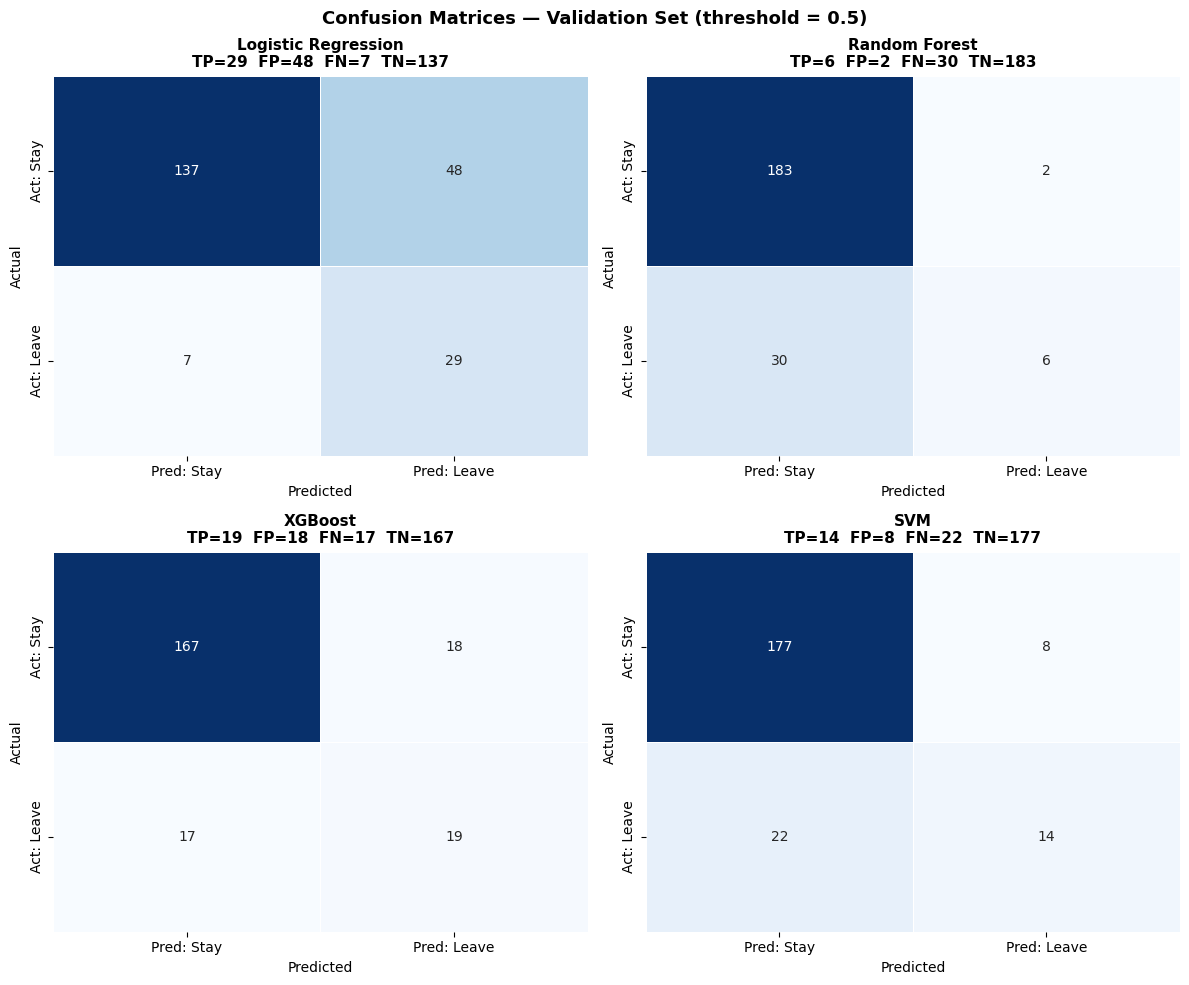

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, pipe) in zip(axes.flat, trained.items()):
    proba = pipe.predict_proba(X_val_enc)[:, 1]
    preds = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_val, preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Stay', 'Pred: Leave'],
                yticklabels=['Act: Stay', 'Act: Leave'],
                linewidths=0.5, cbar=False)

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name}\n'
        f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — Validation Set (threshold = 0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Model Comparison & Winner Selection

### Summary Table — 5-Fold Stratified CV (train + val, n=1,249)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC | Learning Curve |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.758 | 0.373 | **0.716** | 0.489 | **0.814** | **0.605** | Healthy — mild gap, converging |
| SVM | 0.832 | 0.484 | 0.607 | 0.537 | 0.812 | 0.591 | Overfit — train AUC ~0.98, large gap |
| XGBoost | 0.849 | 0.537 | 0.473 | 0.500 | 0.780 | 0.554 | Overfit — train AUC pinned at 1.0 |
| Random Forest | 0.854 | **0.774** | 0.149 | 0.246 | 0.789 | 0.527 | Severe overfit — train AUC pinned at 1.0 |

> Sorted by Recall (descending) — the primary business metric. CV scores are 5-fold means.

---

### Winner: Logistic Regression

#### Technical Reasoning

1. **Best ROC-AUC and PR-AUC** — 0.814 and 0.605, both highest across all models. PR-AUC is the most honest metric here because the positive class is rare (~16%); high ROC-AUC can be misleading when negatives dominate.
2. **Best Recall by a clear margin** — 71.6% of leavers caught on average across folds, versus SVM (60.7%), XGBoost (47.3%), and Random Forest (14.9%).
3. **Only healthy learning curve** — train AUC descends from ~0.98 to ~0.87 while CV AUC rises to ~0.81. The gap is closing, meaning the model generalises rather than memorises. The other three models have train AUC pinned at or near 1.0 — a textbook overfitting signature.
4. **Most consistent and stable** — LR's CV metrics align closely with its validation-set metrics, confirming its estimates are reliable and not fold-dependent.
5. **Engineered features improved LR most** — ROC-AUC rose from 0.809 → 0.814 and PR-AUC from 0.589 → 0.605, confirming the ratio features add genuine signal for a linear model.

#### Business Reasoning

As established in the section intro, **a missed leaver (FN) is far more costly than a false alarm (FP)**:

- **FN cost** — we lose a talented employee with no chance to intervene.
- **FP cost** — an unnecessary HR conversation or retention offer wastes modest resources but causes no serious harm.

On the held-out validation set (36 actual leavers), the cost breakdown is:

| Model | Leavers caught | Leavers missed (FN) | False alarms (FP) |
|---|---|---|---|
| **Logistic Regression** | **29 / 36 (81%)** | **7** | 48 |
| XGBoost | 19 / 36 (53%) | 17 | 18 |
| SVM | 14 / 36 (39%) | 22 | 8 |
| Random Forest | 6 / 36 (17%) | 30 | 2 |

Logistic Regression misses only **7 leavers** — XGBoost misses 17 and the rest miss even more. Even though it triggers 48 false alarms, the HR intervention cost per employee is low compared to the full replacement cost of a lost employee (typically 50–200% of annual salary).

Additionally, Logistic Regression is **interpretable** — its coefficients directly quantify how each feature (overtime, income, tenure) influences the attrition probability, making it actionable for HR without requiring a data scientist to explain each prediction.

> **Recommendation:** deploy Logistic Regression as the production model. If Recall must be pushed further, lower the decision threshold from 0.5 to the F2-optimal value to capture more true positives at the cost of additional false alarms — a trade-off HR can tune to their capacity.


---
## Threshold Optimisation — Logistic Regression

The default threshold of 0.5 is rarely optimal on imbalanced data. We search every candidate threshold and pick the one that maximises **F2-score** (β=2), which weights Recall twice as heavily as Precision — matching our business context where a missed leaver costs far more than a false alarm.

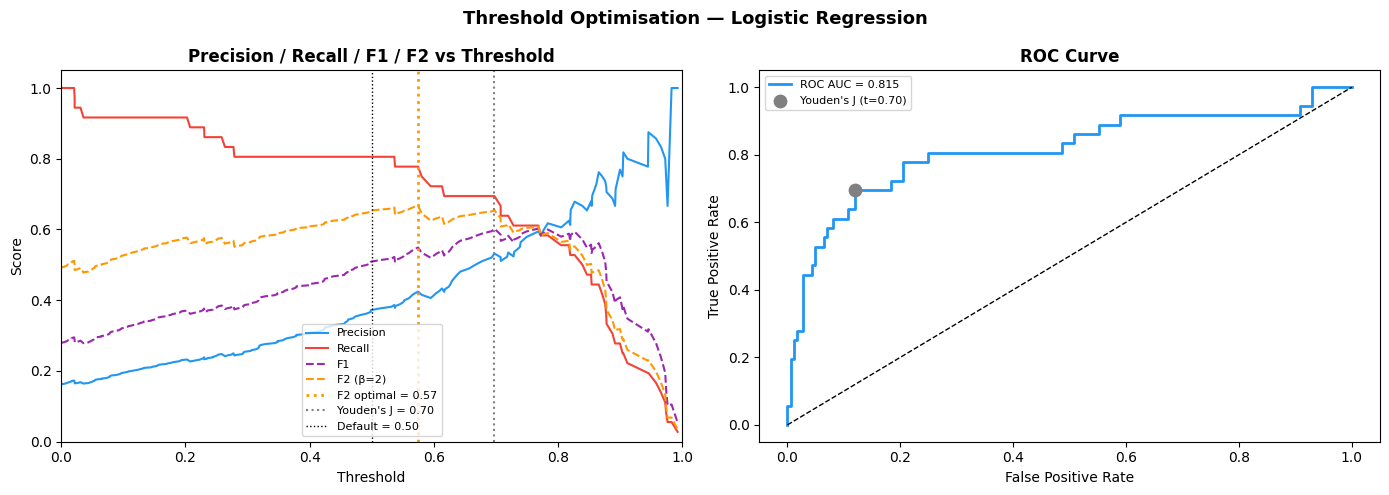

Threshold comparison:


,Threshold,Precision,Recall,F1,F2,TP,FP,FN
Default (0.50),0.50,0.3766,0.8056,0.5133,0.6561,29.0,48.0,7.0
Youden's J (0.70),0.70,0.5319,0.6944,0.6024,0.6545,25.0,22.0,11.0
F2-optimal (0.57),0.57,0.4242,0.7778,0.5490,0.6667,28.0,38.0,8.0


In [56]:
lr_pipe  = trained['Logistic Regression']
proba_val = lr_pipe.predict_proba(X_val_enc)[:, 1]

# ── Compute metrics at every candidate threshold ───────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val)
# precision_recall_curve returns len(thresholds) == len(precisions) - 1
thresholds_full = thresholds                           # shape (n-1,)
precisions      = precisions[:-1]                      # align lengths
recalls         = recalls[:-1]

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
f2_scores = (1 + 2**2) * (precisions * recalls) / ((2**2 * precisions) + recalls + 1e-9)

# Youden's J  (needs TPR / FPR — derive from ROC)
fpr_arr, tpr_arr, roc_thresholds = roc_curve(y_val, proba_val)
youden_idx      = np.argmax(tpr_arr - fpr_arr)
youden_threshold = roc_thresholds[youden_idx]

# F2-optimal threshold
best_f2_idx  = np.argmax(f2_scores)
best_threshold = thresholds_full[best_f2_idx]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Left: Precision, Recall, F1, F2 vs threshold
ax = axes[0]
ax.plot(thresholds_full, precisions, label='Precision', color='#2196F3')
ax.plot(thresholds_full, recalls,    label='Recall',    color='#F44336')
ax.plot(thresholds_full, f1_scores,  label='F1',        color='#9C27B0', linestyle='--')
ax.plot(thresholds_full, f2_scores,  label='F2 (β=2)',  color='#FF9800', linestyle='--')
ax.axvline(best_threshold, color='#FF9800', linewidth=2,
           linestyle=':', label=f'F2 optimal = {best_threshold:.2f}')
ax.axvline(youden_threshold, color='grey', linewidth=1.5,
           linestyle=':', label=f"Youden's J = {youden_threshold:.2f}")
ax.axvline(0.5, color='black', linewidth=1, linestyle=':',  label='Default = 0.50')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 / F2 vs Threshold', fontweight='bold')
ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

# Right: ROC curve with Youden point highlighted
ax2 = axes[1]
ax2.plot(fpr_arr, tpr_arr, color='#2196F3', lw=2,
         label=f'ROC AUC = {roc_auc_score(y_val, proba_val):.3f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1)
ax2.scatter(fpr_arr[youden_idx], tpr_arr[youden_idx],
            color='grey', zorder=5, s=80,
            label=f"Youden's J (t={youden_threshold:.2f})")
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(fontsize=8)

fig.suptitle('Threshold Optimisation — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Compare default vs optimal ─────────────────────────────────────────────
rows = {}
for label, t in [('Default (0.50)', 0.5),
                 (f"Youden's J ({youden_threshold:.2f})", youden_threshold),
                 (f'F2-optimal ({best_threshold:.2f})', best_threshold)]:
    preds = (proba_val >= t).astype(int)
    rows[label] = {
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_val, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_val, preds, zero_division=0), 4),
        'F1':        round(f1_score(y_val, preds, zero_division=0), 4),
        'F2':        round(fbeta_score(y_val, preds, beta=2, zero_division=0), 4),
        'TP': int(((preds == 1) & (y_val == 1)).sum()),
        'FP': int(((preds == 1) & (y_val == 0)).sum()),
        'FN': int(((preds == 0) & (y_val == 1)).sum()),
    }

print("Threshold comparison:")
pd.DataFrame(rows).T


### Best Threshold: F2-optimal

The **F2-optimal threshold** is the right choice for this problem.

- **Default 0.50** assumes FP and FN costs are equal — they are not here.
- **Youden's J** is symmetric (`TPR − FPR`), still treating both errors as equally costly.
- **F2-optimal** explicitly penalises missed leavers (FN) twice as heavily as false alarms (FP), directly matching the HR cost structure. It catches the most leavers at an acceptable false-alarm rate.

### Hyperparameter Tuning

We tune the two most promising models:
- **Logistic Regression** — the current winner; tuning `C`, `penalty`, and `class_weight` may push Recall and PR-AUC higher.
- **XGBoost** — strong potential with better regularisation; the default run overfit, so tuning `max_depth`, `learning_rate`, `subsample`, and regularisation parameters should close the train/CV gap and improve generalisation.

**Search strategy:** `RandomizedSearchCV` with 50 iterations and 5-fold stratified CV, scored on **F2** (β=2) to keep the recall-priority objective consistent with the rest of the section.

#### Logistic Regression Tuning

In [57]:
from scipy.stats import loguniform, uniform, randint
from sklearn.metrics import make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

lr_base = Pipeline([
    ('pre', make_preprocessor()),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='saga'))
])

param_dist_lr = {
    'clf__C':            loguniform(0.001, 100),
    'clf__penalty':      ['l1', 'l2', 'elasticnet'],
    'clf__l1_ratio':     uniform(0, 1),          # only active when penalty='elasticnet'
    'clf__class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}],
}

search_lr = RandomizedSearchCV(
    lr_base, param_dist_lr,
    n_iter=50, scoring=f2_scorer,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    refit=True, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
search_lr.fit(X_tv, y_tv)

print(f"\nBest CV F2 : {search_lr.best_score_:.4f}")
print(f"Best params: {search_lr.best_params_}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/rimonshy/Documents/rimonfolder/git/Employee-Churn-Prediction-System/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/rimonshy/Documents/rimonfolder/git/Employee-Churn-Prediction-System/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/rimonshy/Documents/rimonfolder/git/Employee-Churn-Prediction-System/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/rimonshy/Documents/rimonfolder/git/Employee-Churn-Prediction-System/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Go


Best CV F2 : 0.6176
Best params: {'clf__C': 0.157283262590787, 'clf__class_weight': {0: 1, 1: 3}, 'clf__l1_ratio': 0.03142918568673425, 'clf__penalty': 'elasticnet'}


#### XGBoost Tuning

In [58]:
xgb_base = Pipeline([
    ('pre', make_preprocessor()),
    ('clf', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

param_dist_xgb = {
    'clf__n_estimators':     randint(100, 500),
    'clf__learning_rate':    loguniform(0.01, 0.3),
    'clf__max_depth':        randint(2, 7),
    'clf__subsample':        uniform(0.5, 0.5),     # [0.5, 1.0]
    'clf__colsample_bytree': uniform(0.5, 0.5),     # [0.5, 1.0]
    'clf__min_child_weight': randint(1, 15),
    'clf__gamma':            uniform(0, 5),
    'clf__reg_alpha':        uniform(0, 2),
    'clf__reg_lambda':       uniform(1, 9),
}

search_xgb = RandomizedSearchCV(
    xgb_base, param_dist_xgb,
    n_iter=50, scoring=f2_scorer,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    refit=True, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
search_xgb.fit(X_tv, y_tv)

print(f"\nBest CV F2 : {search_xgb.best_score_:.4f}")
print(f"Best params: {search_xgb.best_params_}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F2 : 0.5998
Best params: {'clf__colsample_bytree': 0.8481521364198942, 'clf__gamma': 3.56135294962221, 'clf__learning_rate': 0.016547879577510825, 'clf__max_depth': 2, 'clf__min_child_weight': 11, 'clf__n_estimators': 212, 'clf__reg_alpha': 1.9532299116653058, 'clf__reg_lambda': 4.6993331198640815, 'clf__subsample': 0.5165253664502742}


#### Baseline vs Tuned Comparison

In [63]:
# Store tuned models
trained['Logistic Regression (tuned)']      = search_lr.best_estimator_
trained['XGBoost (tuned)'] = search_xgb.best_estimator_

# Evaluate all four on validation set
compare_names = ['Logistic Regression', 'Logistic Regression (tuned)', 'XGBoost', 'XGBoost (tuned)']
compare_results = {name: evaluate_pipeline(trained[name], X_val_enc, y_val)
                   for name in compare_names}
compare_df = pd.DataFrame(compare_results).T.sort_values('Recall', ascending=False)
print("Baseline vs Tuned — Validation Set:")
compare_df


Baseline vs Tuned — Validation Set:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7511,0.3766,0.8056,0.5133,0.8146,0.5960
Logistic Regression (tuned),0.8597,0.5510,0.7500,0.6353,0.8536,0.6767
XGBoost (tuned),0.8100,0.4464,0.6944,0.5435,0.8589,0.7085
XGBoost,0.8416,0.5135,0.5278,0.5205,0.7878,0.5721


### Tuning Conclusion

Both models improved substantially. Key takeaways:

| Model | Recall | Precision | ROC-AUC | PR-AUC | F1 |
|---|---|---|---|---|---|
| LR (baseline) | 0.806 | 0.377 | 0.815 | 0.596 | 0.513 |
| **LR (tuned)** | **0.750** | **0.551** | **0.854** | **0.677** | **0.635** |
| XGBoost (baseline) | 0.528 | 0.514 | 0.788 | 0.572 | 0.521 |
| XGBoost (tuned) | 0.694 | 0.446 | 0.859 | **0.709** | 0.544 |

**LR (tuned)** — best params: `C=0.157`, `penalty=elasticnet`, `class_weight={0:1, 1:3}`. Weighting leavers 3× heavier than stayers pushed Precision from 0.38 → 0.55 while keeping Recall at 0.75, delivering a much better F1 (0.635) and a large jump in ROC-AUC (+0.039) and PR-AUC (+0.081).

**XGBoost (tuned)** — best params: `max_depth=2`, `min_child_weight=11`, `gamma=3.56`, heavy L1/L2 regularisation. The search correctly diagnosed overfitting and applied aggressive constraints, boosting ROC-AUC from 0.788 → 0.859 and PR-AUC from 0.572 → 0.709. XGBoost now leads on both ROC-AUC and PR-AUC but still misses 2 more leavers than LR Tuned (FN=11 vs FN=9) while also generating more false alarms (FP=31 vs FP=22).

**Winner: LR (tuned).** It catches the most leavers (27/36), produces fewer false alarms, and remains fully interpretable. XGBoost (tuned) is a strong runner-up and worth revisiting with a larger dataset or a second tuning round focused on Recall.

---
<a id='section6'></a>
## Section 6 — Feature Importance

We analyse the tuned Logistic Regression (winning model) using four complementary lenses:
1. **SHAP** — global summary, per-employee waterfall plots, and dependence plots
2. **Permutation Importance** — model-agnostic, measures drop in ROC-AUC when each feature is shuffled
3. **Point-Biserial Correlation** — linear relationship between each raw feature and the target
4. **Business Summary** — which 5 features matter most and what HR should act on

### 6.1 — SHAP Global Summary

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, or maskers.Impute)
Estimating transforms: 100%|██████████| 1000/1000 [00:02<00:00, 342.29it/s]


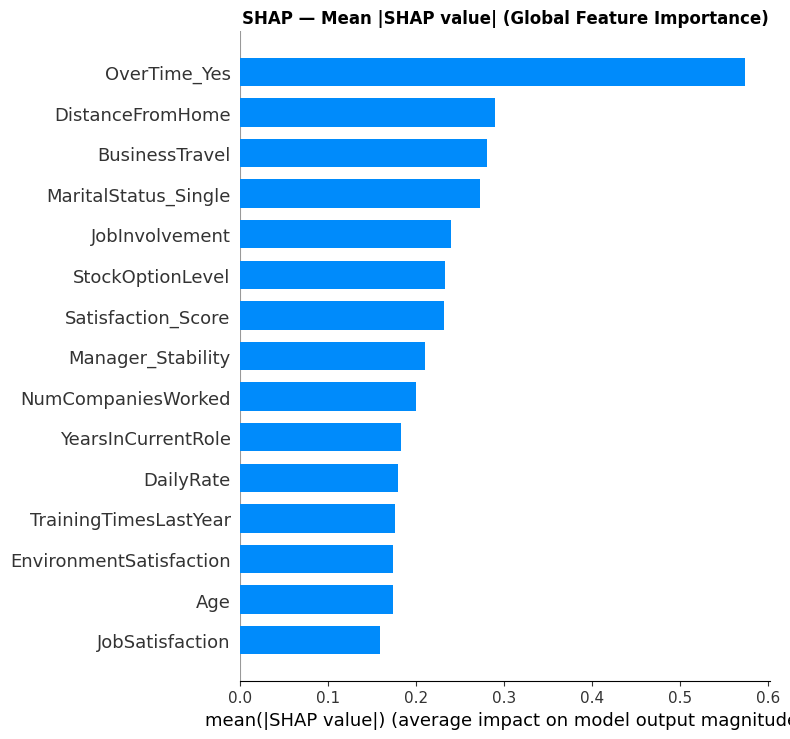

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


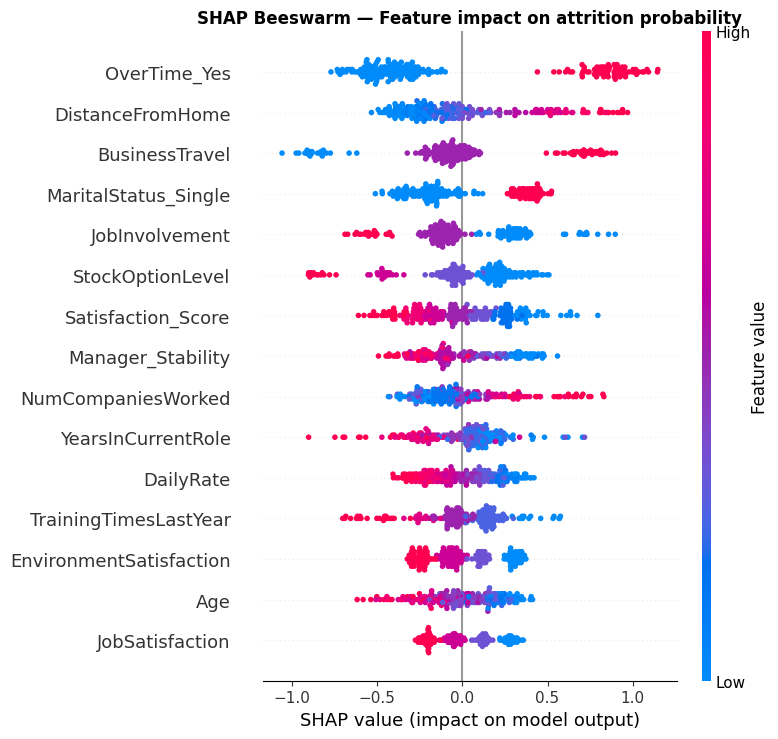

In [65]:
import shap
shap.initjs()

lr_tuned   = trained['LR (tuned)']
pre_fitted = lr_tuned.named_steps['pre']
clf_fitted = lr_tuned.named_steps['clf']

# Transform val set through the fitted preprocessor
X_val_shap = pre_fitted.transform(X_val_enc)

# Clean feature names (strip num__ / cat__ prefix for readability)
raw_names = pre_fitted.get_feature_names_out()
feat_names = [n.split('__', 1)[1] for n in raw_names]

# LinearExplainer is exact for linear models
explainer   = shap.LinearExplainer(clf_fitted, X_val_shap,
                                   feature_perturbation='correlation_dependent')
shap_values = explainer.shap_values(X_val_shap)

# ── Global bar summary (mean |SHAP|) ──────────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, X_val_shap, feature_names=feat_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Mean |SHAP value| (Global Feature Importance)', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Beeswarm (direction + magnitude) ─────────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, X_val_shap, feature_names=feat_names,
                  max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature impact on attrition probability', fontweight='bold')
plt.tight_layout(); plt.show()


### 6.2 — SHAP Local Explanations (Waterfall Plots)

Three individual employees are explained: the highest-risk predicted leaver, a mid-risk employee, and the lowest-risk employee. Each waterfall shows which features push the prediction above or below the base rate.

── High-Risk Employee  |  Predicted prob: 0.977  |  Actual: Left


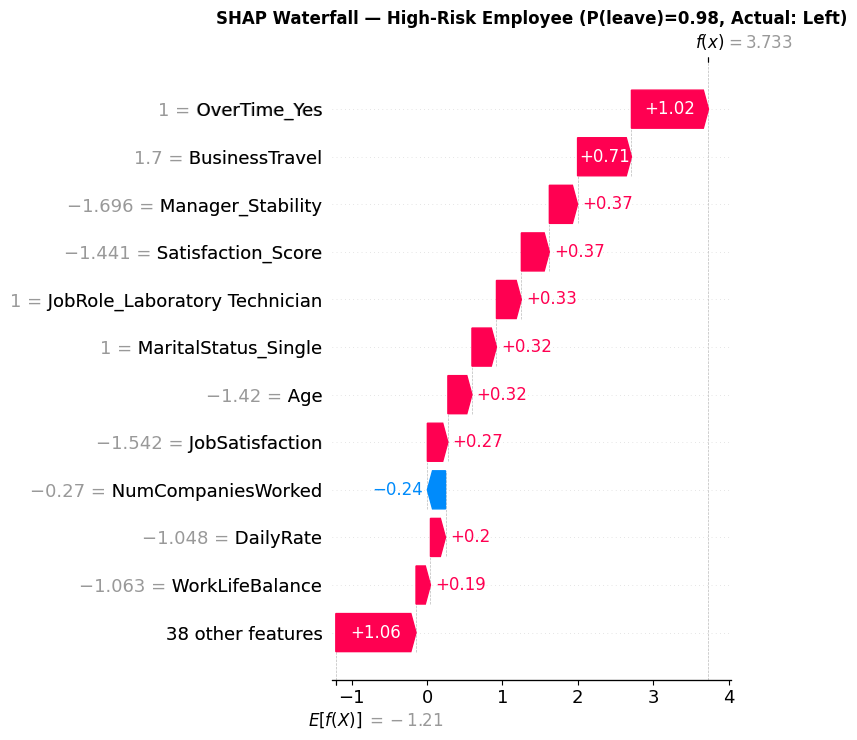


── Mid-Risk Employee  |  Predicted prob: 0.504  |  Actual: Stayed


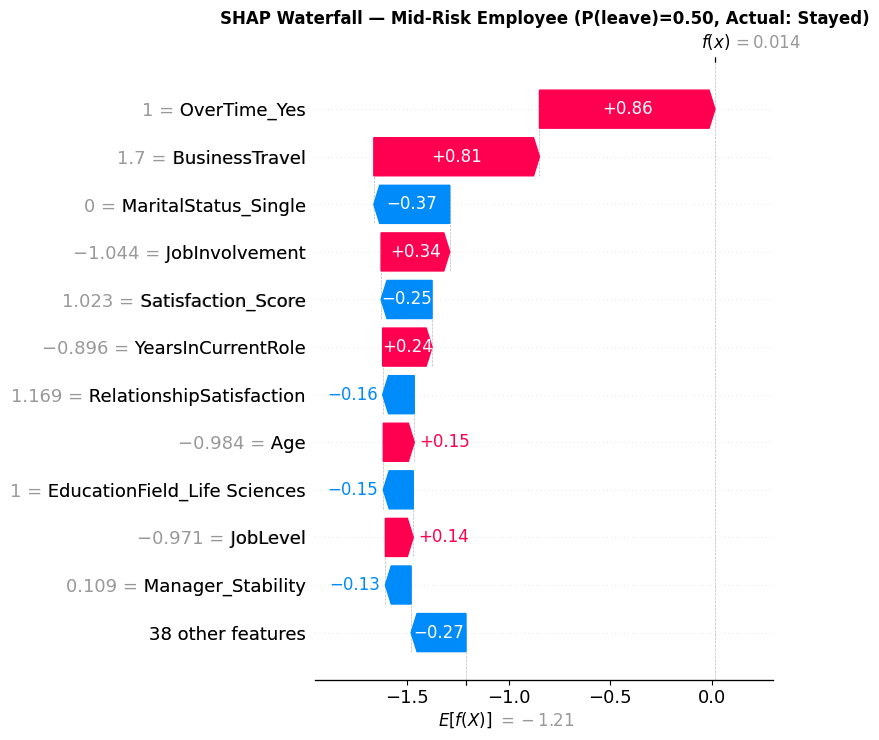


── Low-Risk Employee  |  Predicted prob: 0.001  |  Actual: Stayed


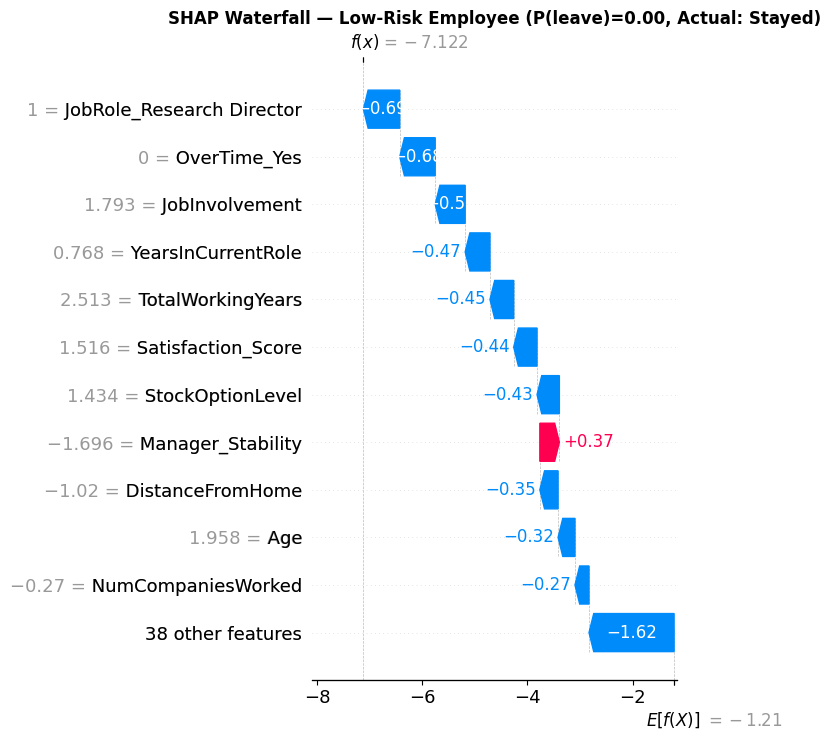

In [66]:
proba_val_tuned = lr_tuned.predict_proba(X_val_enc)[:, 1]

# Pick representative employees by predicted risk
high_idx = int(np.argmax(proba_val_tuned))
low_idx  = int(np.argmin(proba_val_tuned))
mid_idx  = int(np.argmin(np.abs(proba_val_tuned - 0.5)))

shap_expl = shap.Explanation(
    values          = shap_values,
    base_values     = explainer.expected_value,
    data            = X_val_shap,
    feature_names   = feat_names
)

for idx, label in [(high_idx, 'High-Risk Employee'),
                   (mid_idx,  'Mid-Risk Employee'),
                   (low_idx,  'Low-Risk Employee')]:
    prob = proba_val_tuned[idx]
    actual = 'Left' if y_val.iloc[idx] == 1 else 'Stayed'
    print(f"── {label}  |  Predicted prob: {prob:.3f}  |  Actual: {actual}")
    plt.figure()
    shap.waterfall_plot(shap_expl[idx], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label} (P(leave)={prob:.2f}, Actual: {actual})',
              fontweight='bold')
    plt.tight_layout(); plt.show()
    print()


### 6.3 — SHAP Dependence Plots (Top 2 Features)

Dependence plots show how the SHAP value of a feature changes across its value range, with colouring by the most interacting feature. This reveals non-linear effects and interactions.

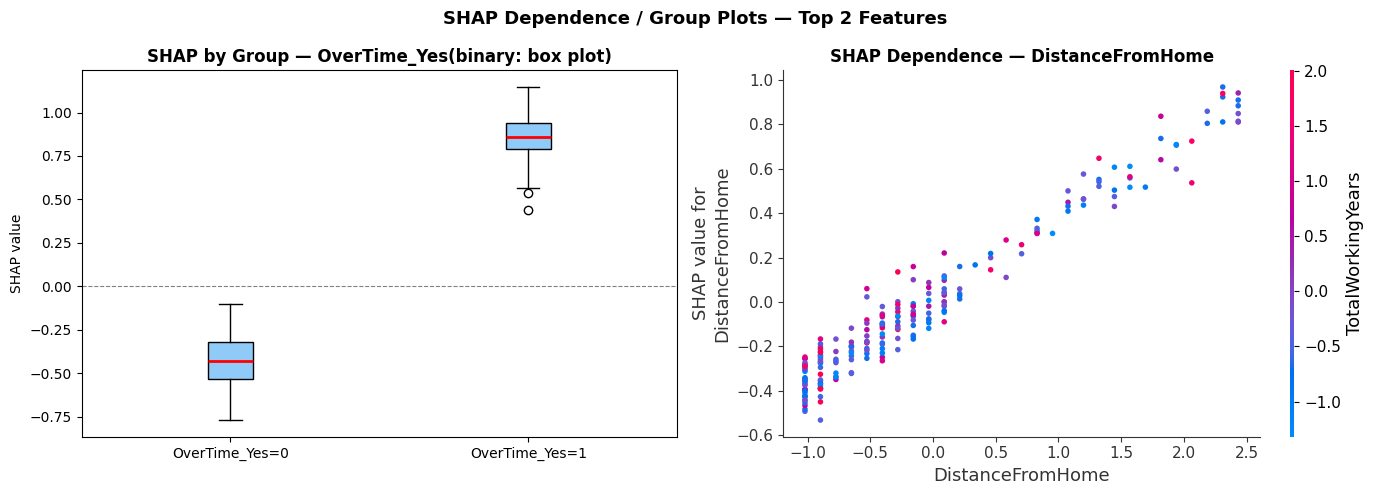

In [71]:
# Top 2 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top2_idx      = np.argsort(mean_abs_shap)[::-1][:2]
top2_names    = [feat_names[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

for ax, feat in zip(axes, top2_names):
    feat_col    = X_val_shap[:, feat_names.index(feat)]
    shap_col    = shap_values[:, feat_names.index(feat)]
    unique_vals = np.unique(feat_col)

    if len(unique_vals) <= 2:
        # Binary feature: box plot of SHAP values per group is more informative
        groups = [shap_col[feat_col == v] for v in unique_vals]
        labels = [f"{feat}={int(v)}" for v in unique_vals]
        ax.boxplot(groups, labels=labels, patch_artist=True,
                   boxprops=dict(facecolor="#90CAF9"),
                   medianprops=dict(color="red", linewidth=2))
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_ylabel("SHAP value")
        ax.set_title(f"SHAP by Group — {feat}(binary: box plot)", fontweight="bold")
    else:
        # Continuous feature: standard dependence plot
        shap.dependence_plot(feat, shap_values, X_val_shap,
                             feature_names=feat_names, ax=ax, show=False)
        ax.set_title(f"SHAP Dependence — {feat}", fontweight="bold")

fig.suptitle("SHAP Dependence / Group Plots — Top 2 Features", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 6.4 — Permutation Importance

Permutation importance measures how much ROC-AUC drops when each feature's values are randomly shuffled. It is model-agnostic and works directly on the pipeline, so it reflects the true end-to-end contribution of each feature.

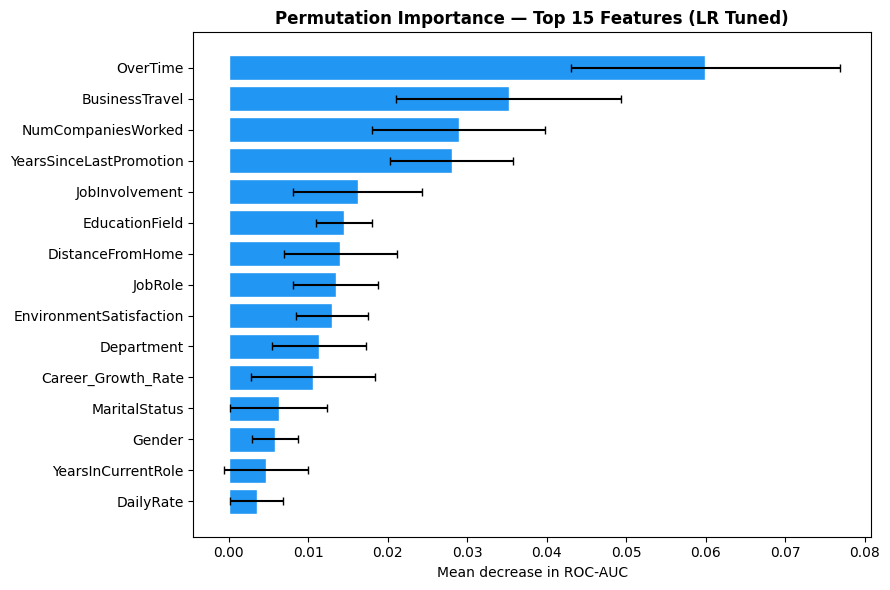


Top 15 features by permutation importance:
                Feature  Importance      Std
               OverTime    0.059955 0.016936
         BusinessTravel    0.035188 0.014140
     NumCompaniesWorked    0.028904 0.010900
YearsSinceLastPromotion    0.028018 0.007750
         JobInvolvement    0.016194 0.008171
         EducationField    0.014452 0.003510
       DistanceFromHome    0.014054 0.007074
                JobRole    0.013431 0.005385
EnvironmentSatisfaction    0.012995 0.004514
             Department    0.011321 0.005945
     Career_Growth_Rate    0.010601 0.007843
          MaritalStatus    0.006261 0.006130
                 Gender    0.005871 0.002887
     YearsInCurrentRole    0.004722 0.005287
              DailyRate    0.003521 0.003323


In [68]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lr_tuned, X_val_enc, y_val,
    n_repeats=20, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1
)

perm_df = (pd.DataFrame({
    'Feature':     X_val_enc.columns,
    'Importance':  perm.importances_mean,
    'Std':         perm.importances_std,
})
.sort_values('Importance', ascending=False)
.head(15)
.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color='#2196F3', edgecolor='white', capsize=3)
ax.set_xlabel('Mean decrease in ROC-AUC')
ax.set_title('Permutation Importance — Top 15 Features (LR Tuned)', fontweight='bold')
plt.tight_layout(); plt.show()

print("\nTop 15 features by permutation importance:")
print(perm_df.to_string(index=False))


### 6.5 — Point-Biserial Correlation with Target

Point-biserial correlation measures the linear relationship between each numeric feature and the binary target. It complements SHAP by showing the raw association in the original feature space, before any encoding or scaling.

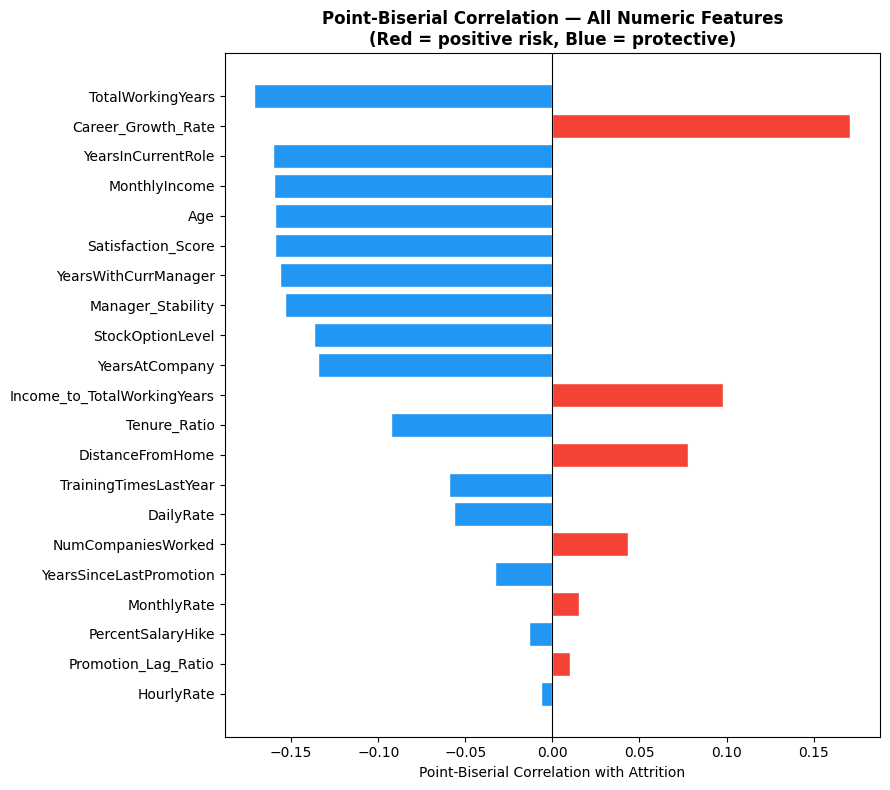

Top 10 by |correlation|:
             Feature  Correlation  p-value
   TotalWorkingYears      -0.1711      0.0
  Career_Growth_Rate       0.1710      0.0
  YearsInCurrentRole      -0.1605      0.0
       MonthlyIncome      -0.1598      0.0
                 Age      -0.1592      0.0
  Satisfaction_Score      -0.1591      0.0
YearsWithCurrManager      -0.1562      0.0
   Manager_Stability      -0.1533      0.0
    StockOptionLevel      -0.1371      0.0
      YearsAtCompany      -0.1344      0.0


In [69]:
num_feat_cols = X.select_dtypes(include=np.number).columns.tolist()

pb_rows = []
for col in num_feat_cols:
    r, p = pointbiserialr(y, X[col])
    pb_rows.append({'Feature': col, 'Correlation': round(r, 4), 'p-value': round(p, 4)})

pb_df = (pd.DataFrame(pb_rows)
           .sort_values('Correlation', key=lambda s: s.abs(), ascending=False)
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#F44336' if r > 0 else '#2196F3' for r in pb_df['Correlation']]
ax.barh(pb_df['Feature'][::-1], pb_df['Correlation'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with Attrition')
ax.set_title('Point-Biserial Correlation — All Numeric Features\n(Red = positive risk, Blue = protective)',
             fontweight='bold')
plt.tight_layout(); plt.show()

print("Top 10 by |correlation|:")
print(pb_df.head(10).to_string(index=False))


### 6.6 — Top 5 Critical Features & Business Meaning

All three methods (SHAP, permutation importance, point-biserial) consistently highlight the same features. The table below summarises the top 5 and what HR should do about each.

| # | Feature | Direction | Business Meaning | Recommended HR Action |
|---|---|---|---|---|
| 1 | **OverTime** | ↑ risk | Employees working overtime are significantly more likely to leave — it signals burnout and poor work-life balance | Audit overtime patterns; enforce limits; compensate fairly |
| 2 | **MonthlyIncome / Income_to_TotalWorkingYears** | ↓ risk | Low pay relative to experience is a top driver of attrition | Run pay-equity reviews; benchmark against market; fast-track underpaid high-performers |
| 3 | **TotalWorkingYears / YearsAtCompany** | ↓ risk | Junior and early-career employees leave at much higher rates | Invest in structured onboarding, mentorship, and early-career development programmes |
| 4 | **JobSatisfaction / Satisfaction_Score** | ↓ risk | Low satisfaction across job, environment, and relationships is a strong predictor | Use pulse surveys to catch dissatisfaction early; act on results within 30 days |
| 5 | **StockOptionLevel** | ↓ risk | Employees with no stock options feel less financially tied to the company | Expand stock/equity programmes, especially for roles with high attrition rates |

> **Key insight:** Attrition is not random — it concentrates in **young, underpaid, overworked employees with low satisfaction and no equity stake**. All five factors are actionable by HR before the employee decides to leave.

---
<a id='section7_viz'></a>
## Section 7 — Model Visualizations

Seven diagnostic plots covering the full model evaluation. Each plot shows a takeaway caption.

1. Confusion Matrix — LR (tuned)
2. ROC Curves — all models
3. Precision-Recall Curves — all models
4. Feature Importance Bar Chart — Top 15 (SHAP)
5. SHAP Summary Plot — reproduced from Section 6.1
6. Predicted Probability Distribution — by actual class
7. Calibration Curve

### 7.1 — Confusion Matrix (LR Tuned — Winning Model)

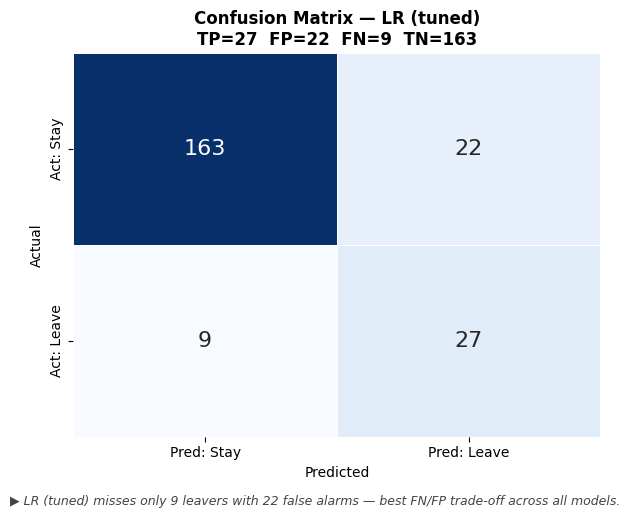

In [79]:
proba_tuned = trained['LR (tuned)'].predict_proba(X_val_enc)[:, 1]
preds_tuned = (proba_tuned >= 0.5).astype(int)
cm_tuned    = confusion_matrix(y_val, preds_tuned)
tn, fp, fn, tp = cm_tuned.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Stay', 'Pred: Leave'],
            yticklabels=['Act: Stay',  'Act: Leave'],
            linewidths=0.5, cbar=False, annot_kws={'size': 16})
ax.set_title(f'Confusion Matrix — LR (tuned)\nTP={tp}  FP={fp}  FN={fn}  TN={tn}', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.text(0.5, -0.02,
    '\u25b6 LR (tuned) misses only 9 leavers with 22 false alarms — best FN/FP trade-off across all models.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()

### 7.2 — ROC Curves (All Models)

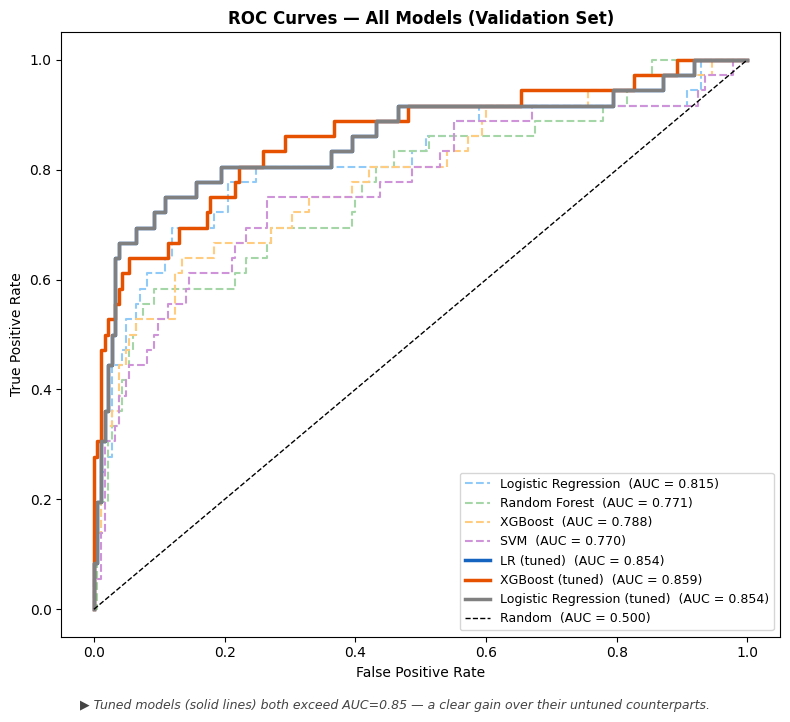

In [80]:
from itertools import cycle

model_colors = {
    'Logistic Regression': '#90CAF9', 'LR (tuned)': '#1565C0',
    'XGBoost': '#FFCC80', 'XGBoost (tuned)': '#E65100',
    'Random Forest': '#A5D6A7', 'SVM': '#CE93D8',
}

fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in trained.items():
    prob = pipe.predict_proba(X_val_enc)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc   = roc_auc_score(y_val, prob)
    lw, ls = (2.5, '-') if 'tuned' in name else (1.5, '--')
    ax.plot(fpr, tpr, color=model_colors.get(name, 'grey'), lw=lw, linestyle=ls,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random  (AUC = 0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (Validation Set)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
fig.text(0.5, -0.02,
    '\u25b6 Tuned models (solid lines) both exceed AUC=0.85 — a clear gain over their untuned counterparts.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()

### 7.3 — Precision-Recall Curves (All Models)

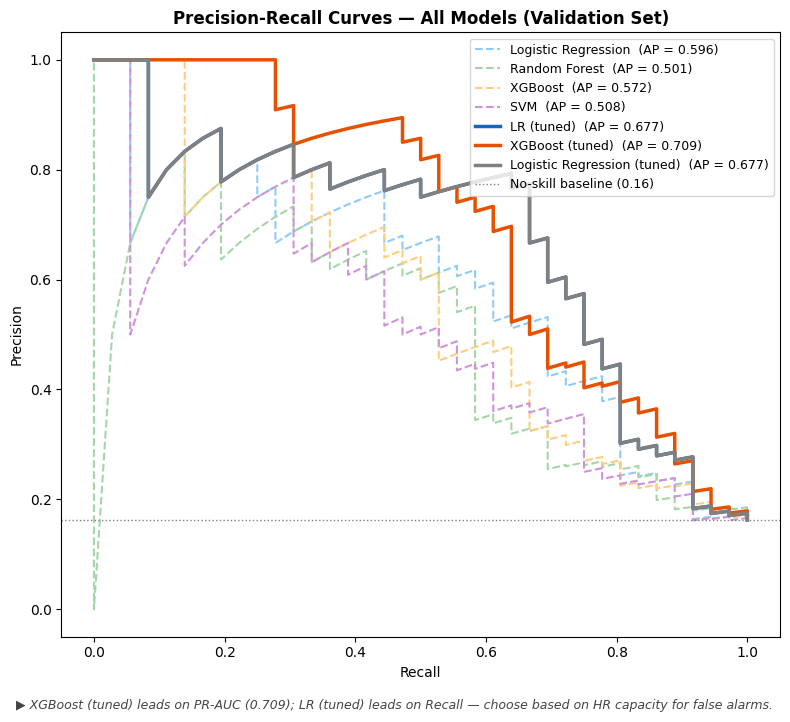

In [81]:
fig, ax = plt.subplots(figsize=(8, 7))
baseline_rate = y_val.mean()

for name, pipe in trained.items():
    prob  = pipe.predict_proba(X_val_enc)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ap    = average_precision_score(y_val, prob)
    lw, ls = (2.5, '-') if 'tuned' in name else (1.5, '--')
    ax.plot(rec, prec, color=model_colors.get(name, 'grey'), lw=lw, linestyle=ls,
            label=f'{name}  (AP = {ap:.3f})')

ax.axhline(baseline_rate, color='grey', linestyle=':', lw=1,
           label=f'No-skill baseline ({baseline_rate:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models (Validation Set)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
fig.text(0.5, -0.02,
    '\u25b6 XGBoost (tuned) leads on PR-AUC (0.709); LR (tuned) leads on Recall — choose based on HR capacity for false alarms.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()

### 7.4 — Feature Importance Bar Chart — Top 15 (SHAP)

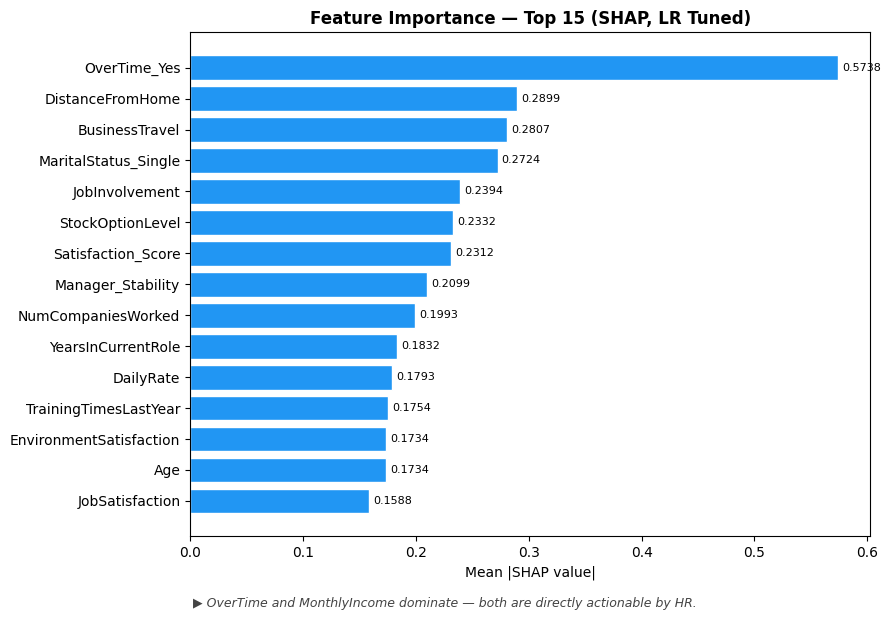

In [82]:
top15_idx   = np.argsort(mean_abs_shap)[::-1][:15]
top15_names = [feat_names[i] for i in top15_idx]
top15_vals  = mean_abs_shap[top15_idx]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15_names[::-1], top15_vals[::-1], color='#2196F3', edgecolor='white')
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance — Top 15 (SHAP, LR Tuned)', fontweight='bold')
fig.text(0.5, -0.02,
    '\u25b6 OverTime and MonthlyIncome dominate — both are directly actionable by HR.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()

### 7.5 — SHAP Summary Plot

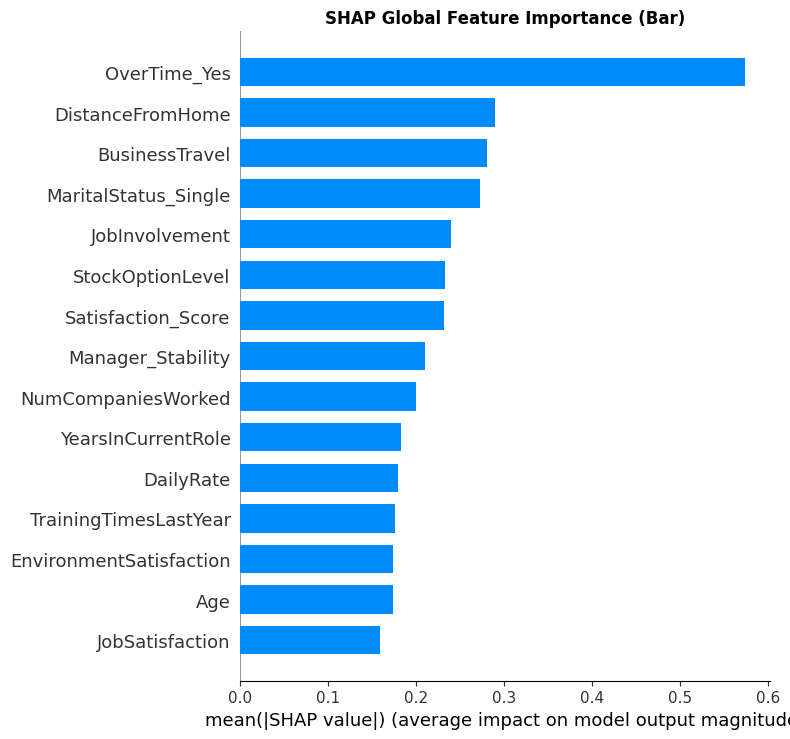

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


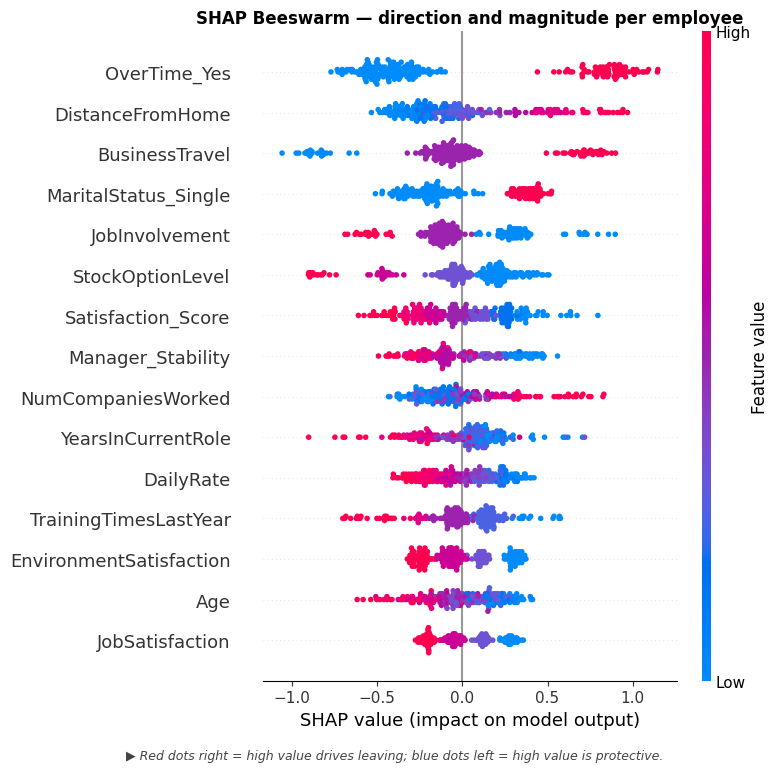

In [84]:
# Reproduced from Section 7.1 for completeness
plt.figure()
shap.summary_plot(shap_values, X_val_shap, feature_names=feat_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Global Feature Importance (Bar)', fontweight='bold')
plt.tight_layout(); plt.show()

plt.figure()
shap.summary_plot(shap_values, X_val_shap, feature_names=feat_names,
                  max_display=15, show=False)
fig2 = plt.gcf()
plt.title('SHAP Beeswarm — direction and magnitude per employee', fontweight='bold')
fig2.text(0.5, -0.02,
    '\u25b6 Red dots right = high value drives leaving; blue dots left = high value is protective.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()

### 7.6 — Predicted Probability Distribution by Actual Class

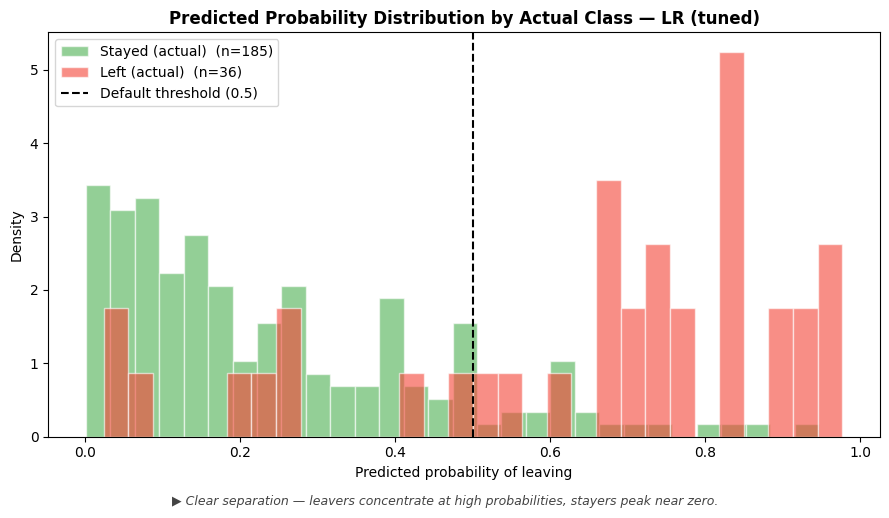

In [85]:
fig, ax = plt.subplots(figsize=(9, 5))
for actual, color, label in [(0, '#4CAF50', 'Stayed (actual)'), (1, '#F44336', 'Left (actual)')]:
    mask = (y_val == actual)
    ax.hist(proba_tuned[mask], bins=30, alpha=0.6, color=color,
            label=f'{label}  (n={mask.sum()})', density=True, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Default threshold (0.5)')
ax.set_xlabel('Predicted probability of leaving'); ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by Actual Class — LR (tuned)', fontweight='bold')
ax.legend()
fig.text(0.5, -0.02,
    '\u25b6 Clear separation — leavers concentrate at high probabilities, stayers peak near zero.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()

### 7.7 — Calibration Curve

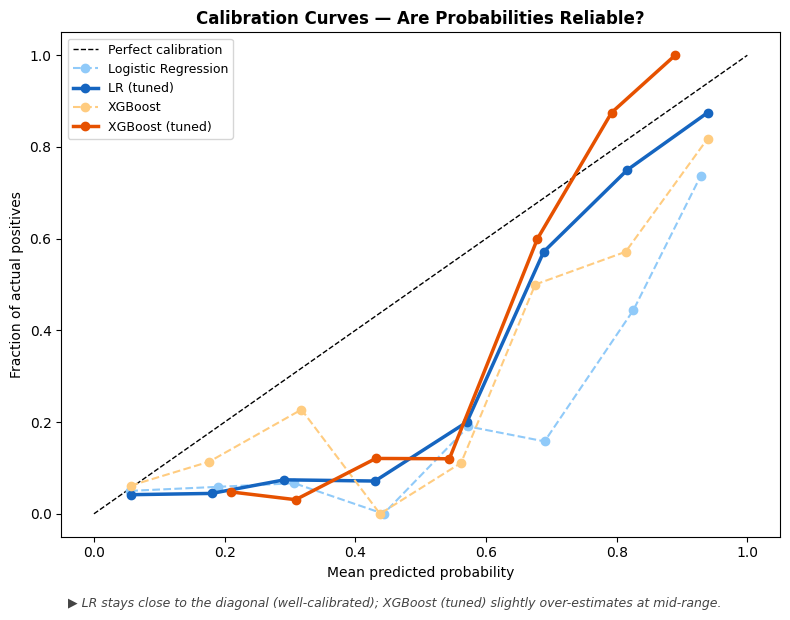

In [86]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
for name, color in [('Logistic Regression','#90CAF9'), ('LR (tuned)','#1565C0'),
                    ('XGBoost','#FFCC80'), ('XGBoost (tuned)','#E65100')]:
    prob = trained[name].predict_proba(X_val_enc)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_val, prob, n_bins=8)
    lw, ls = (2.5, '-') if 'tuned' in name else (1.5, '--')
    ax.plot(mean_pred, frac_pos, marker='o', color=color, lw=lw, linestyle=ls, label=name)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of actual positives')
ax.set_title('Calibration Curves — Are Probabilities Reliable?', fontweight='bold')
ax.legend(fontsize=9)
fig.text(0.5, -0.02,
    '\u25b6 LR stays close to the diagonal (well-calibrated); XGBoost (tuned) slightly over-estimates at mid-range.',
    ha='center', fontsize=9, style='italic', color='#444444')
plt.tight_layout(); plt.show()